# Photon Subtraction in Graph State
2026\. 07\. 06.  Test the other code - star case

In [2]:
def star_lattice_adjacency(n_nodes, g=1.0):
    """
    Star graph with node labels:
        center node = 1
        outer nodes = 2, 3, ..., n_nodes

    Python internal indices:
        node 1 -> index 0
        node 2 -> index 1
        ...
        node n_nodes -> index n_nodes - 1

    Returns:
        Adj : weighted adjacency matrix
        pos : plotting position dictionary with internal indices
    """

    m = n_nodes
    Adj = np.zeros((m, m))

    center = 0  # physical node label 1

    # connect center node 1 to all outer nodes 2,...,n_nodes
    for j in range(1, m):
        Adj[center, j] = g
        Adj[j, center] = g

    # plotting positions
    pos = {}
    pos[0] = (0.0, 0.0)  # center node 1

    n_outer = m - 1
    for j in range(1, m):
        theta = 2 * np.pi * (j - 1) / n_outer
        pos[j] = (np.cos(theta), np.sin(theta))

    return Adj, pos

## 1. Set the graph state

##### Initial parameters, modules and functions

In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
# Graph: paper-style 6-node graph, labels 1-6 1-2-(3,4)-5-6 graph

# Adj = np.array([[0, 1, 0, 0, 0, 0],
#                 [1, 0, 1, 1, 0, 0],
#                 [0, 1, 0, 0, 1, 0],
#                 [0, 1, 0, 0, 1, 0],
#                 [0, 0, 1, 1, 0, 1],
#                 [0, 0, 0, 0, 1, 0]], dtype=float)



n_nodes = 5   # total nodes: center 1 + outer 2,3,4,5   
g = 0.3

Adj, pos = star_lattice_adjacency(n_nodes, g=g)
m = Adj.shape[0]

center_idx = 0  # center node index in internal representation

print("center node =", center_idx + 1)
print("number of outer nodes =", n_nodes - 1)
print("total node number =", m)

# Phase-space convention: q = (x1, ..., xm, p1, ..., pm)
I_m = np.eye(m)
Z_m = np.zeros((m, m))
Omega = np.block([[Z_m, I_m], [-I_m, Z_m]]) # [0, I; -I, 0] symplectic form
J = Omega.T # [0, -I; I, 0] symplectic form in Mattia's convention

# CZ symplectic matrix
G = np.block([[I_m, Z_m], [Adj, I_m]])

# Input covariance, paper convention: vacuum variance = 1
squeezing_db = np.full(m, 0.2, dtype=float) # 단위는 dB
#squeezing_db = np.array([3, 4, 12, 5, 3, 5], dtype=float) # mode별로 squeezing 다르게 주는 경우

s = 10 ** (squeezing_db / 10) # 단위 변환
V0 = np.diag(np.concatenate([s, 1 / s])) # diag(s_1, ..., s_m, 1/s_1, ..., 1/s_m)


# Graph-state covariance
V = G @ V0 @ G.T # maybe later we adjust this code to general mixed case.

# Photon-subtraction mode
# annhilation operator 기준으로 photon subtraction을 설명하기 위한 f이다. 복소수가 가능하며 C^(m)이다.
# a(f) = f1 a1 + f2 a2 + ... + fm am 이다.

#f_sub = np.array([1, 0, 0, 0, 0, 0], dtype=complex) # a(f_sub) = sum f_sub[i] a_i

# 중심 모드에다가 photon subtraction을 적용하는 경우, f_sub = (1, 0, 0, ..., 0)이다.
# f_sub = np.zeros(m, dtype=complex)
# f_sub[center_idx] = 1.0
# f_sub = f_sub / np.linalg.norm(f_sub)




# outer star에다가 photon subtraction을 적용하는 경우, f_sub = (0, 1, 0, ..., 0)이다. (즉 leaf node 1에 photon subtraction을 적용하는 경우)
sub_node = 2         # physical node label
sub_idx = sub_node - 1  # Python index


f_sub = np.zeros(m, dtype=complex)
f_sub[sub_idx] = 2.0
f_sub = f_sub / np.linalg.norm(f_sub)







# mattia convention으로 표현, g_sub이 전부 실수 R^(2m)이다. -> 이는 quadrature 기준으로 중첩을 설명하기 위한 convention이다.
# 수식적으로는 g = (Re(f), -Im(f))^T)이고, Q(g) = x(g), Q(Jg) = p(g)이다.

g_sub = np.concatenate([np.real(f_sub), -np.imag(f_sub)]) # g_sub = (Re(f_sub), -Im(f_sub)) in phase space , a(f_sub) = 1/2 (Q(g_sub)+iQ(Jg_sub)) 
Jg_sub = J @ g_sub
Pi_g = np.outer(g_sub, g_sub) + np.outer(Jg_sub, Jg_sub) # Πg =ggT + Jg(Jg)T , projection matrix for the subtracted mode

sub_label = f"mode {sub_node}"



center node = 1
number of outer nodes = 4
total node number = 5


##### graph plotting function

In [4]:
from matplotlib.colors import LinearSegmentedColormap

blue = LinearSegmentedColormap.from_list(
    "blue",
    ["#3f5f87", "#7b8a70", "#fffbe6"]
)

red = LinearSegmentedColormap.from_list(
    "red",
    ["#18051f", "#5b2a86", "#d44a1c", "#ffc247", "#fffbe6"]
)

In [5]:
def plot_graph_from_matrix(
    W,
    node_values=None,
    title="",
    threshold=1e-6,
    pos=None,
    cmap=blue,
    vmin=None,
    vmax=None,
    colorbar_label="",
    draw_labels=None,
    labels=None
):
    """
    W: weighted adjacency matrix 
    node_values: optional node color values, e.g. kurtosis, purity, nullifier_var
    """

    W_plot = np.array(W, dtype=float).copy()
    G_plot = nx.from_numpy_array(W_plot)

    # automatic layout - 어느정도 정렬된 그래프를 그려준다. 더 깔끔하게 그리고 싶을때는 pos를 직접 지정
    if pos is None:
        pos = nx.kamada_kawai_layout(G_plot)


    # label이 주어지지 않으면 기본적으로 1부터 시작
    if labels is None:
        labels = {i: i + 1 for i in range(W_plot.shape[0])}

    # node_values가 있으면 논문 figure처럼 label을 기본적으로 끔
    if draw_labels is None:
        draw_labels = node_values is None

    # plotting // 사이즈 고정
    plt.figure(figsize=(4.2, 3.2), dpi=180)
    
    
    # graph edge(선) 그리기
    nx.draw_networkx_edges(
        G_plot,
        pos,
        edge_color="#5b668a",
        width=1.4,
        alpha=0.75
    )

    # graph node(노드) 그리기
    if node_values is None:
        nx.draw_networkx_nodes(
            G_plot,
            pos,
            node_color="white",
            edgecolors="black",
            linewidths=1.1,
            node_size=700
        )

    else:
        node_values_plot = np.asarray(node_values, dtype=float)

        # colorbar range를 node_values에서 자동 설정
        if vmin is None:
            vmin = np.nanmin(node_values_plot)
        if vmax is None:
            vmax = np.nanmax(node_values_plot)

        # 모든 node value가 같은 경우 colorbar error 방지
        if np.isclose(vmin, vmax):
            vmin -= 1e-9
            vmax += 1e-9

        nodes = nx.draw_networkx_nodes(
            G_plot,
            pos,
            node_color=node_values_plot,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            edgecolors="#444444",
            linewidths=1.1,
            node_size=500
        )

        cbar = plt.colorbar(nodes, fraction=0.045, pad=0.03)
        if colorbar_label:
            cbar.set_label(colorbar_label, fontsize=9)
        cbar.ax.tick_params(labelsize=8)

    # graph label 그리기
    if draw_labels:
        nx.draw_networkx_labels(
            G_plot,
            pos,
            labels=labels,
            font_color="black",
            font_size=9
        )

    plt.title(title, fontsize=10, pad=6)
    plt.axis("equal")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return pos

##### matrix visualization function

In [6]:
def show_mat(M, name="M", digits=3, tol=1e-10):
    M_show = np.array(M, dtype=float).copy()
    M_show[np.abs(M_show) < tol] = 0

    n, m = M_show.shape
    df = pd.DataFrame(
        M_show,
        index=[f"{i+1}" for i in range(n)],
        columns=[f"{j+1}" for j in range(m)]
    )

    print(name)
    display(df.style.format(f"{{:.{digits}f}}"))

In [7]:
def draw_mat(M, title="", cmap="bwr", label=False, digits=2,
             vlim=None, figsize=(5, 4.5), grid=False):
    M = np.asarray(M)
    n, m = M.shape

    vmax = np.percentile(np.abs(M), 95) if vlim is None else vlim
    vmax = vmax if vmax > 0 else 1

    fig, ax = plt.subplots(figsize=figsize, dpi=180)
    im = ax.imshow(
        M,
        cmap=cmap,
        vmin=-vmax,
        vmax=vmax,
        interpolation="nearest",
        aspect="equal"
    )

    ax.set_xticks(range(m), labels=range(1, m + 1))
    ax.set_yticks(range(n), labels=range(1, n + 1))
    ax.tick_params(
        top=True, labeltop=True,
        bottom=False, labelbottom=False,
        labelsize=8
    )

    # grid for every matrix cell
    if grid:
        ax.set_xticks(np.arange(-0.5, m, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
        ax.grid(which="minor", color="k", linewidth=0.18, alpha=0.15)
        ax.tick_params(which="minor", bottom=False, left=False)

    if label:
        for i in range(n):
            for j in range(m):
                ax.text(
                    j, i, f"{M[i, j]:.{digits}f}",
                    ha="center", va="center", fontsize=6
                )

    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

In [8]:
from matplotlib.colors import TwoSlopeNorm, PowerNorm, Normalize
import numpy as np
import matplotlib.pyplot as plt

def draw_phase_matrix(
    M,
    title="",
    mode_labels=None,
    cmap="Reds",
    positive=True,
    vmin=None,
    vmax=None,
    gamma=1.5,
    tick_step=1,
    figsize=(5, 4.5),
    grid=True,
):
    """
    M: 2m x 2m phase-space matrix
       ordering = (x1,...,xm,p1,...,pm)

    positive=True:
        use Reds colormap with PowerNorm.
        Good when A_minus is nonnegative or mostly positive.

    positive=False:
        use diverging colormap centered at 0 only when vmin < 0 < vmax.
        If the requested range does not contain 0, use regular Normalize.
    """

    M = np.asarray(M, dtype=float)
    N = M.shape[0]
    assert M.shape[0] == M.shape[1], "M must be square."
    assert N % 2 == 0, "M must be 2m x 2m."

    m = N // 2

    if mode_labels is None:
        mode_labels = np.arange(1, m + 1)

    labels = (
        [rf"$x_{{{i}}}$" for i in mode_labels]
        + [rf"$p_{{{i}}}$" for i in mode_labels]
    )

    fig, ax = plt.subplots(figsize=figsize, dpi=170)

    if positive:
        if vmin is None:
            vmin = 0
        if vmax is None:
            vmax = np.nanmax(M)

        if np.isclose(vmin, vmax):
            vmax = vmin + 1

        norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax)

        im = ax.imshow(
            M,
            cmap=cmap,
            norm=norm,
            interpolation="nearest",
            aspect="equal"
        )

    else:
        if vmin is None and vmax is None:
            a = max(abs(np.nanmin(M)), abs(np.nanmax(M)))
            a = a if a > 0 else 1
            vmin = -a
            vmax = a

        elif vmin is None:
            a = abs(vmax)
            vmin = -a
            vmax = a

        elif vmax is None:
            a = abs(vmin)
            vmin = -a
            vmax = a

        if np.isclose(vmin, vmax):
            vmax = vmin + 1

        if vmin < 0 < vmax:
            norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
        else:
            norm = Normalize(vmin=vmin, vmax=vmax)

        im = ax.imshow(
            M,
            cmap=cmap,
            norm=norm,
            interpolation="nearest",
            aspect="equal"
        )

    # tick labels
    ticks = np.arange(0, N, tick_step)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    if tick_step == 1 and N <= 30:
        ax.set_xticklabels([labels[i] for i in ticks], fontsize=8)
        ax.set_yticklabels([labels[i] for i in ticks], fontsize=8)
    else:
        ax.set_xticklabels(ticks + 1, fontsize=8)
        ax.set_yticklabels(ticks + 1, fontsize=8)

    ax.tick_params(
        top=True,
        labeltop=True,
        bottom=False,
        labelbottom=False,
        length=3
    )

    # cell grid
    if grid:
        ax.set_xticks(np.arange(-0.5, N, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, N, 1), minor=True)
        ax.grid(which="minor", color="k", linewidth=0.18, alpha=0.12)
        ax.tick_params(which="minor", bottom=False, left=False)

    # x/p block separator
    ax.axhline(m - 0.5, color="k", linewidth=1.0, alpha=0.55)
    ax.axvline(m - 0.5, color="k", linewidth=1.0, alpha=0.55)

    ax.set_title(title, fontsize=13, pad=8)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=9)

    plt.tight_layout()
    plt.show()
    print(f"vmin={vmin:.3g}, vmax={vmax:.3g}")

##### Graph-State Sanity

In [9]:
print("m =", m)

print("Adj =\n", Adj)
print("V =\n", V)

print("f_sub =", f_sub)
print("f_sub shape =", f_sub.shape)

eigvals_physical = np.linalg.eigvalsh(V + 1j * Omega)
print("physical covariance(V + iOmega):", np.min(eigvals_physical) >= -1e-10)
#print("min eigenvalue of V + iOmega =", np.min(eigvals_physical))

m = 5
Adj =
 [[0.  0.3 0.3 0.3 0.3]
 [0.3 0.  0.  0.  0. ]
 [0.3 0.  0.  0.  0. ]
 [0.3 0.  0.  0.  0. ]
 [0.3 0.  0.  0.  0. ]]
V =
 [[1.04712855 0.         0.         0.         0.         0.
  0.31413856 0.31413856 0.31413856 0.31413856]
 [0.         1.04712855 0.         0.         0.         0.31413856
  0.         0.         0.         0.        ]
 [0.         0.         1.04712855 0.         0.         0.31413856
  0.         0.         0.         0.        ]
 [0.         0.         0.         1.04712855 0.         0.31413856
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         1.04712855 0.31413856
  0.         0.         0.         0.        ]
 [0.         0.31413856 0.31413856 0.31413856 0.31413856 1.33195886
  0.         0.         0.         0.        ]
 [0.31413856 0.         0.         0.         0.         0.
  1.04923416 0.09424157 0.09424157 0.09424157]
 [0.31413856 0.         0.         0.         0.         0.
  0.09424157 1.04

chosen: x - Γp
nullifier variances = [0.75077394 0.9730399  0.9730399  0.9730399  0.9730399 ]
below vacuum: [ True  True  True  True  True]
Adj_eff =
 [[0.         0.23584705 0.23584705 0.23584705 0.23584705]
 [0.23584705 0.         0.         0.         0.        ]
 [0.23584705 0.         0.         0.         0.        ]
 [0.23584705 0.         0.         0.         0.        ]
 [0.23584705 0.         0.         0.         0.        ]]


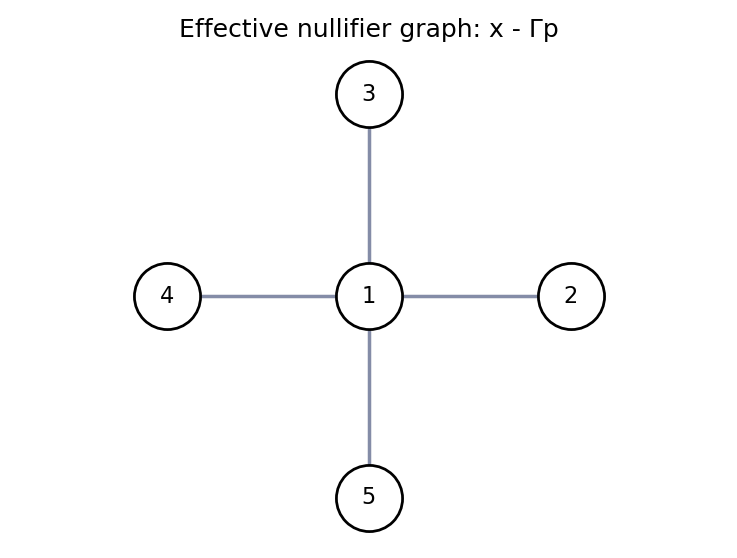

In [10]:
# Effective nullifier graph from V
V_xx = V[:m, :m]
V_xp = V[:m, m:]
V_px = V[m:, :m]
V_pp = V[m:, m:]

# nullfier 1 -> delta1 = p - Gamma1 x 꼴인 경우
Gamma1 = V_px @ np.linalg.pinv(V_xx)
Vd1 = V_pp - Gamma1 @ V_xp - V_px @ Gamma1.T + Gamma1 @ V_xx @ Gamma1.T


# nullfier 2 -> delta2 = x - Gamma2 p 꼴인 경우
Gamma2 = V_xp @ np.linalg.pinv(V_pp)
Vd2 = V_xx - Gamma2 @ V_px - V_xp @ Gamma2.T + Gamma2 @ V_pp @ Gamma2.T

# choose better nullifier
if np.trace(Vd1) <= np.trace(Vd2):
    Gamma_eff = Gamma1
    V_delta = Vd1
    nullifier_type = "p - Γx"
else:
    Gamma_eff = Gamma2
    V_delta = Vd2
    nullifier_type = "x - Γp"

nullifier_var = np.diag(V_delta)




print("chosen:", nullifier_type)
# nullifier variances 출력
print("nullifier variances =", nullifier_var)

# check nullifier variances below vacuum
print("below vacuum:", nullifier_var < 1)

# 해당 nullifer variances로 나온 effective adjacency matrix 출력
print("Adj_eff =\n", Gamma_eff)


# plot the graph using the graph plotting function defined above 
# plot_graph_from_matrix (W=Gamma_eff, node_values=kurtosis같은 노드별 값(기본은 none), title=f"(제목)", pos=pos(기본은 none))

#Adj, pos_star = star_lattice_adjacency(n_nodes, g=1.0)
pos_star = pos

pos = plot_graph_from_matrix(
    Gamma_eff,
    node_values=None,
    title=f"Effective nullifier graph: {nullifier_type}",
    pos= pos_star
    )

## 2. Photon Subtraction on the graph

##### A Matrix for Photon Subtraction

Pi_g projector check: True
A_minus symmetric check: True
A_minus = 


,1,2,3,4,5,6,7,8,9,10
1,2.048,0.000,0.000,0.000,0.000,0.000,0.321,0.614,0.614,0.614
2,0.000,0.046,0.000,0.000,0.000,0.307,0.000,0.000,0.000,0.000
3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
6,0.000,0.307,0.000,0.000,0.000,2.048,0.000,0.000,0.000,0.000
7,0.321,0.000,0.000,0.000,0.000,0.000,0.050,0.096,0.096,0.096
8,0.614,0.000,0.000,0.000,0.000,0.000,0.096,0.184,0.184,0.184
9,0.614,0.000,0.000,0.000,0.000,0.000,0.096,0.184,0.184,0.184
10,0.614,0.000,0.000,0.000,0.000,0.000,0.096,0.184,0.184,0.184


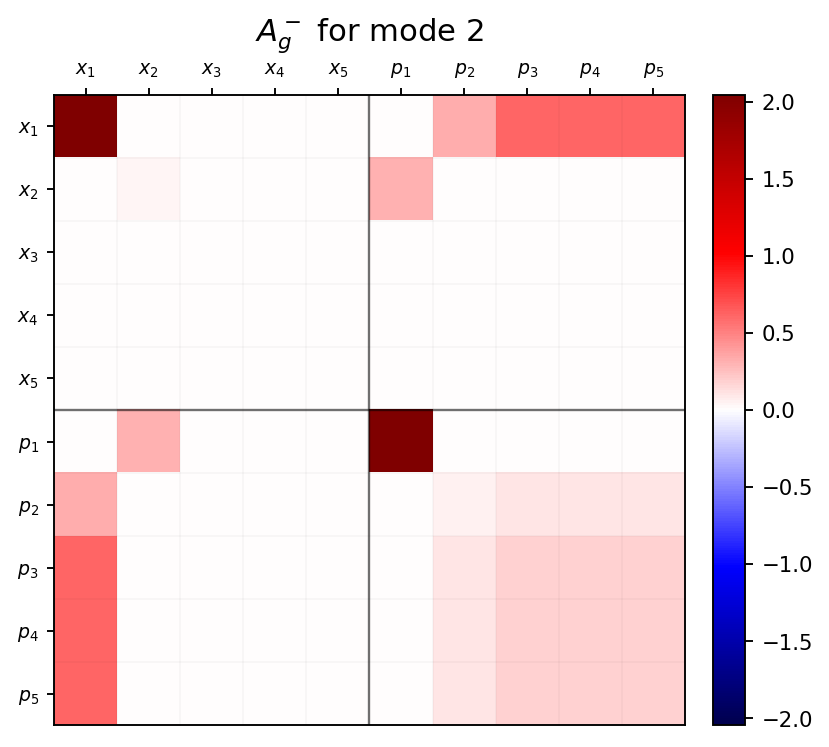

vmin=-2.05, vmax=2.05


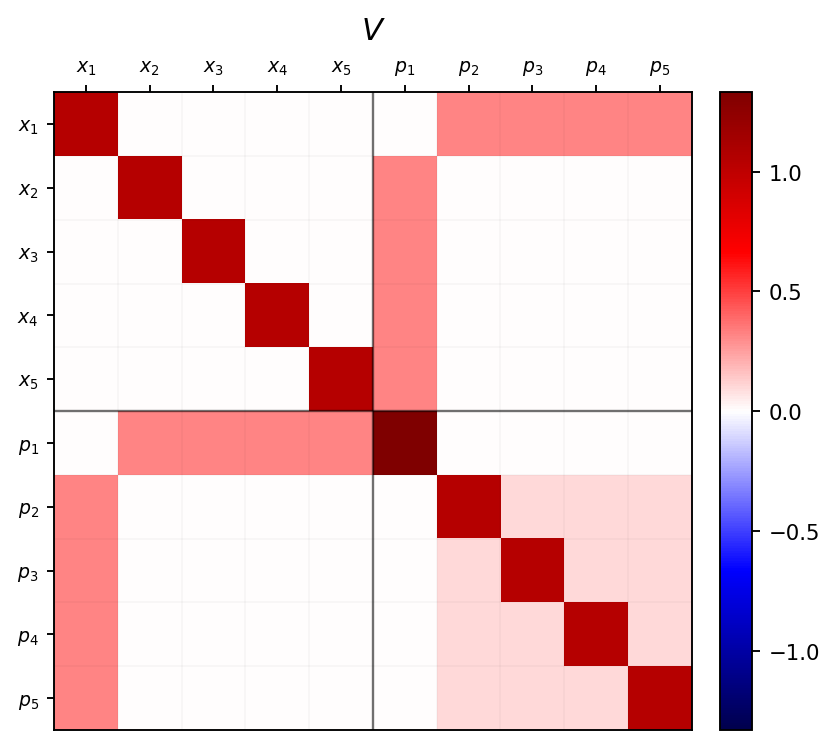

vmin=-1.33, vmax=1.33


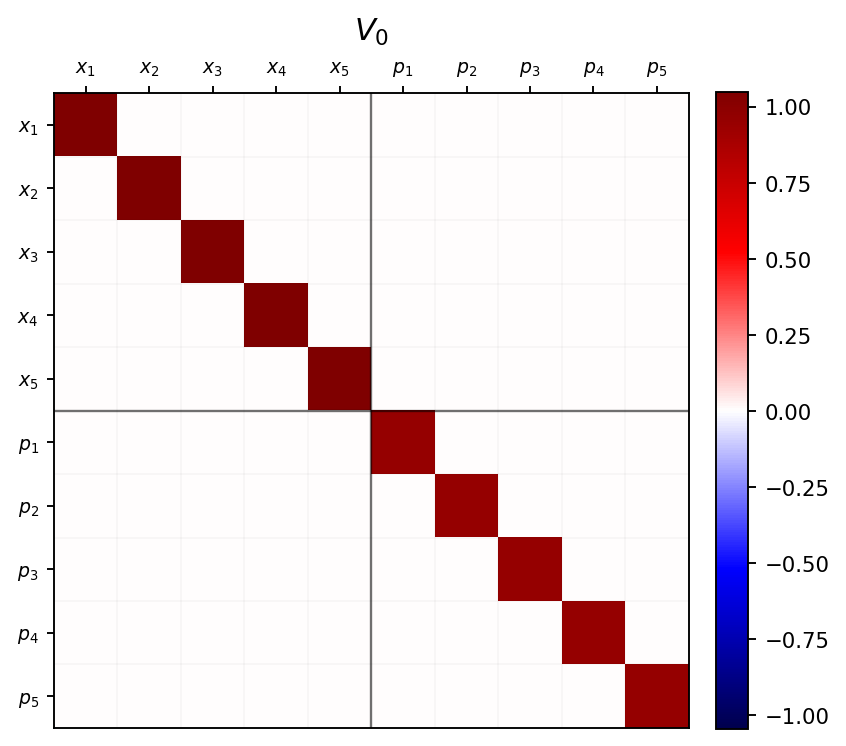

vmin=-1.05, vmax=1.05


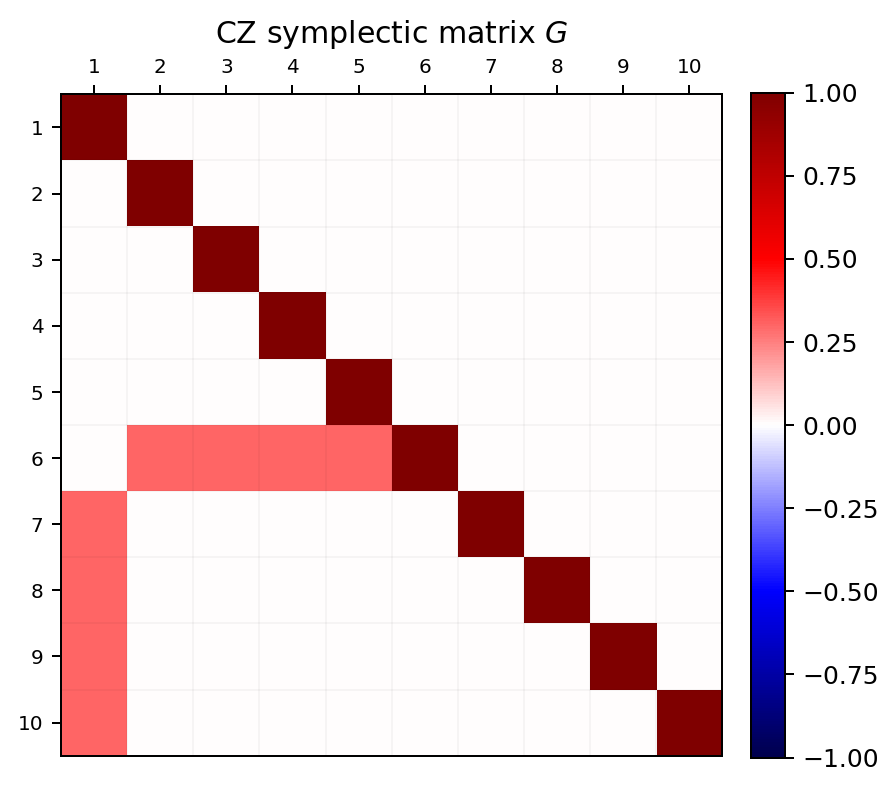

In [ ]:
# A_minus matrix
# A_minus = 2 (V - I) Πg (V - I) / Tr[(V - I) Πg]

I_2m = np.eye(2 * m) # 2m x 2m identity matrix, m은 모드 수

denom = np.trace((V - I_2m) @ Pi_g) # 분모 계산, Tr[(V - I) Πg] , 이거의 4배값이 photon subtraction의 성공확률

# print("denom =", denom)
# 예외처리
if np.isclose(denom, 0):
    raise ValueError("denom is close to zero: photon subtraction mode may be vacuum-like.")

A_minus = 2 * (V - I_2m) @ Pi_g @ (V - I_2m) / denom

print("Pi_g projector check:", bool(np.linalg.norm(Pi_g @ Pi_g - Pi_g) < 1e-10))
print("A_minus symmetric check:", bool(np.linalg.norm(A_minus - A_minus.T) < 1e-10))
#print("A_minus =\n", A_minus)
show_mat(A_minus, name="A_minus = ")

#draw_mat(A_minus, r"$A_g^-$")
draw_phase_matrix(
    A_minus,
    title = rf"$A_g^-$ for {sub_label}",
    positive=False,
    cmap="seismic",
    tick_step=1,
    figsize=(5, 4.5),
    grid=True
)
draw_phase_matrix(
    V,
    title=r"$V$",
    positive=False,
    cmap="seismic",
    tick_step=1,
    figsize=(5, 4.5),
    grid=True
)
draw_phase_matrix(
    V0,
    title=r"$V_0$",
    positive=False,
    cmap="seismic",
    tick_step=1,
    figsize=(5, 4.5),
    grid=True
)
draw_mat(G, title=r"CZ symplectic matrix $G$", cmap="seismic", label=False, digits=1,grid=True)

#### Excess Kurtosis Analysis

v_p = [1.33195886 1.04923416 1.04923416 1.04923416 1.04923416]
a_p = [2.04815835 0.05030996 0.18433425 0.18433425 0.18433425]
K_ex_p = [-1.10150074 -0.00628064 -0.06698952 -0.06698952 -0.06698952]


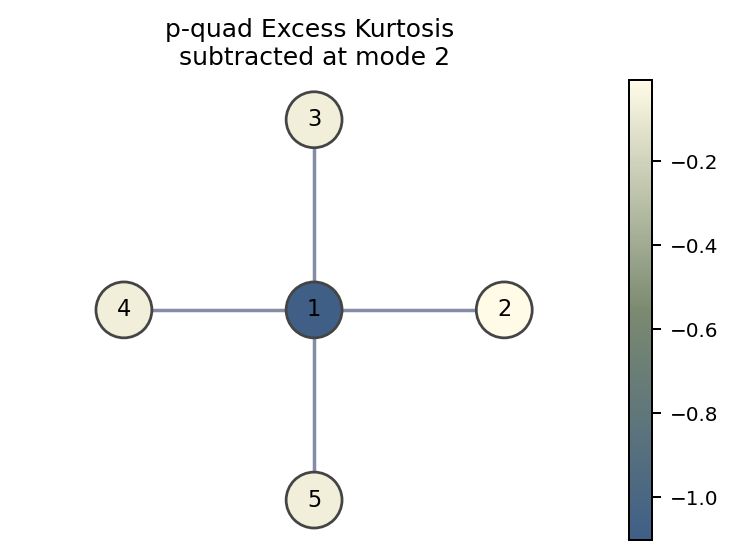

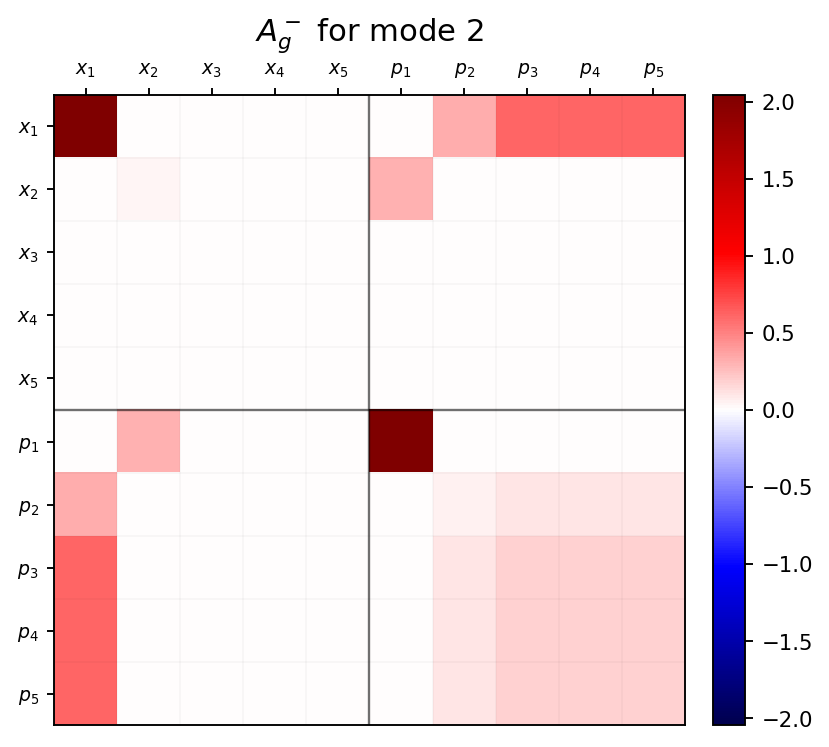

vmin=-2.05, vmax=2.05
v_x = [1.04712855 1.04712855 1.04712855 1.04712855 1.04712855]
a_x = [2.04815835 0.04609875 0.         0.         0.        ]
K_ex_x = [-1.31354966 -0.00533431 -0.         -0.         -0.        ]


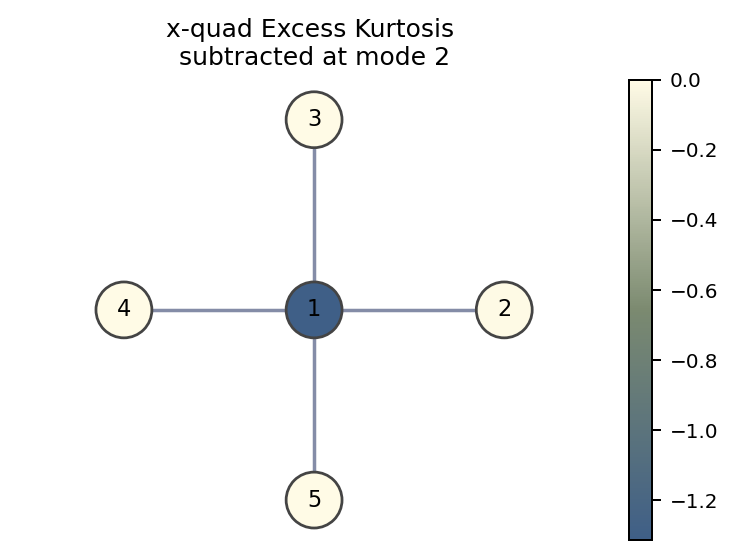

In [12]:
# Node-wise p-quadrature excess kurtosis

p_indices = np.arange(m, 2 * m) # p-quadrature는 phase space 벡터의 뒤쪽 m개 요소에 해당하므로, 인덱스가 m부터 2m-1까지인 부분을 선택

v_p = np.diag(V)[p_indices] # photon subtraction 전의 p-quadrature variance, V 행렬의 뒤쪽 m개 대각 원소에 해당
a_p = np.diag(A_minus)[p_indices] # photon subtraction으로 인한 p-quadrature variance 변화량, A_minus 행렬의 뒤쪽 m개 대각 원소에 해당

K_ex_p = -3 * (a_p ** 2) / ((v_p + a_p) ** 2) # <Q(f)^k>_T를 통해 excess kurtosis p-quadrature 계산, 

print("v_p =", v_p)
print("a_p =", a_p)
print("K_ex_p =", K_ex_p)

pos = plot_graph_from_matrix(
    Gamma_eff,
    node_values=K_ex_p,
    title=f"p-quad Excess Kurtosis \nsubtracted at {sub_label}",
    pos=pos,
    draw_labels=True
)
draw_phase_matrix(
    A_minus,
    title = rf"$A_g^-$ for {sub_label}",
    positive=False,
    cmap="seismic",
    tick_step=1,
    figsize=(5, 4.5),
    grid=True
)

# Node-wise x-quadrature excess kurtosis

x_indices = np.arange(0, m) # x-quadrature는 phase space 벡터의 앞쪽 m개 요소에 해당하므로, 인덱스가 0부터 m-1까지인 부분을 선택

v_x = np.diag(V)[x_indices] # photon subtraction 전의 x-quadrature variance, V 행렬의 앞쪽 m개 대각 원소에 해당
a_x = np.diag(A_minus)[x_indices] # photon subtraction으로 인한 x

K_ex_x = -3 * (a_x ** 2) / ((v_x + a_x) ** 2) # <Q(f)^k>_T를 통해 excess kurtosis x-quadrature 계산,

print("v_x =", v_x)
print("a_x =", a_x)
print("K_ex_x =", K_ex_x)

pos = plot_graph_from_matrix(
    Gamma_eff,
    node_values=K_ex_x,
    title=f"x-quad Excess Kurtosis \nsubtracted at {sub_label}",
    pos=pos,
    draw_labels=True
)

##### Additional Analysis - Wigner negativity

In [13]:
def reduced_matrices(V, A, subset, m):
    """
    V, A: full 2m x 2m matrices
    subset: list of mode indices,
            e.g. [1] for node 1, [1, 3, 6] for nodes 1,3,6
    m: number of modes
    """
    subset = np.array(subset, dtype=int)-1

    inds = np.concatenate([subset, m + subset])

    V_sub = V[np.ix_(inds, inds)]
    A_sub = A[np.ix_(inds, inds)]

    return V_sub, A_sub, inds

In [14]:
V_k, A_k, inds = reduced_matrices(V, A_minus, subset=[1,2,3], m=m) # node 1에 해당하는 mode만 남긴 reduced matrix, subset=[1]은 node 1을 의미, m은 전체 모드 수

show_mat(V_k)
show_mat(A_k)

M


,1,2,3,4,5,6
1,1.047,0.000,0.000,0.000,0.314,0.314
2,0.000,1.047,0.000,0.314,0.000,0.000
3,0.000,0.000,1.047,0.314,0.000,0.000
4,0.000,0.314,0.314,1.332,0.000,0.000
5,0.314,0.000,0.000,0.000,1.049,0.094
6,0.314,0.000,0.000,0.000,0.094,1.049


M


,1,2,3,4,5,6
1,2.048,0.000,0.000,0.000,0.321,0.614
2,0.000,0.046,0.000,0.307,0.000,0.000
3,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.307,0.000,2.048,0.000,0.000
5,0.321,0.000,0.000,0.000,0.050,0.096
6,0.614,0.000,0.000,0.000,0.096,0.184


In [15]:
def nodewise_negativity_quantities(V, A, m):
    N_vals = np.zeros(m)   # N_k = Tr(V_k^{-1} A_k)
    W0_vals = np.zeros(m)  # W_k(0)

    for k in range(1, m + 1):   # 1-indexed node label
        V_k, A_k, _ = reduced_matrices(V, A, [k], m)

        N_k = np.trace(np.linalg.inv(V_k) @ A_k)
        W0_k = (2 - N_k) / (2 * (2 * np.pi) * np.sqrt(np.linalg.det(V_k)))

        N_vals[k - 1] = N_k
        W0_vals[k - 1] = W0_k

    return N_vals, W0_vals

min W0_vals = -0.1006473348375786


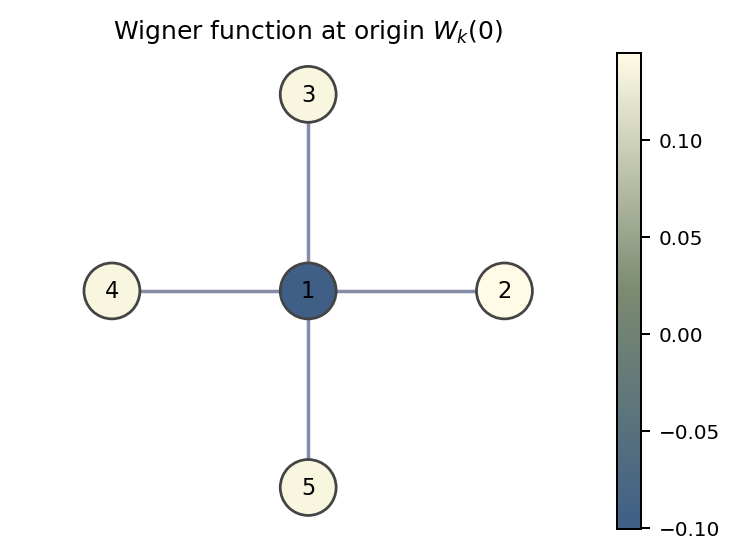

In [16]:
N_vals, W0_vals = nodewise_negativity_quantities(V, A_minus, m)

#print("N_vals =", N_vals)
#print("W0_vals =", W0_vals)
print("min W0_vals =", np.min(W0_vals))
# plot_graph_from_matrix(
#     Adj,
#     node_values=W0_vals,
#     title="Wigner function at origin $W_k(0)$",
#     pos=pos,
#     cmap="nipy_spectral", 
#     vmin=np.min(W0_vals),
#     draw_labels=True
# )



pos = plot_graph_from_matrix(
    Adj,
    node_values=W0_vals,
    title="Wigner function at origin $W_k(0)$",
    pos=pos,
    draw_labels=True
)

In [17]:
def nodewise_gaussian_wigner_origin(V, m):
    WG0 = np.zeros(m)

    for k in range(1, m + 1):
        V_k, _, _ = reduced_matrices(V, np.zeros_like(V), subset=[k], m=m)
        WG0[k - 1] = 1 / ((2 * np.pi) * np.sqrt(np.linalg.det(V_k)))

    return WG0

##### Ploting Wigner function

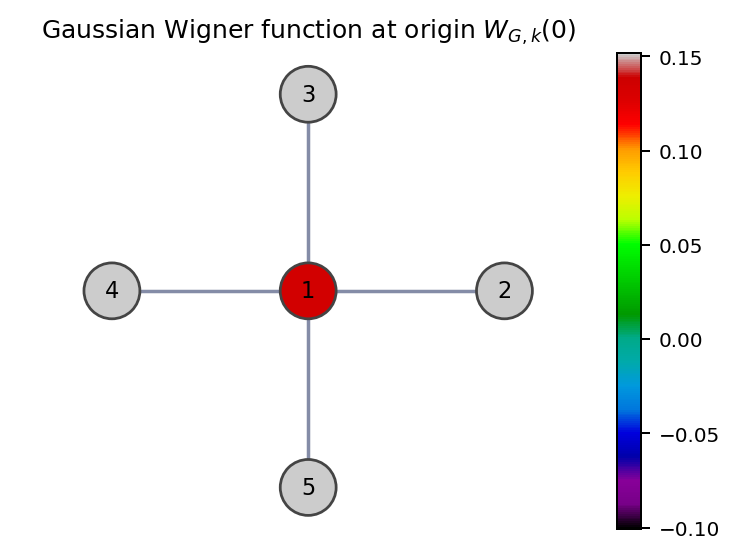

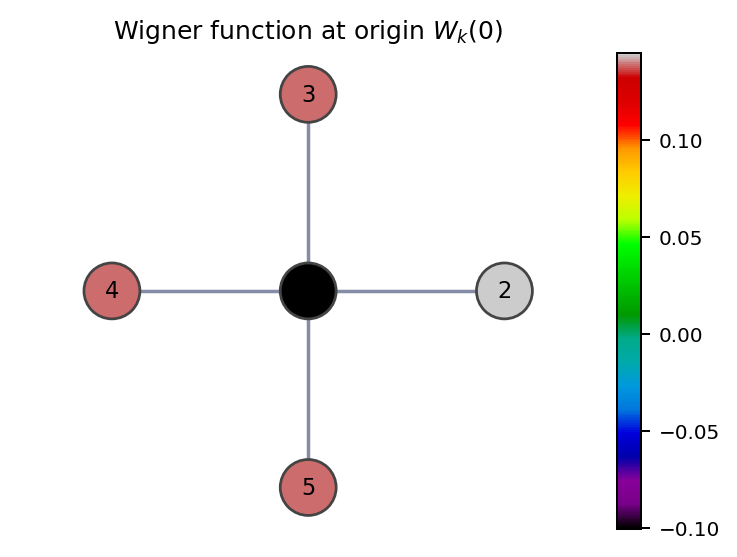

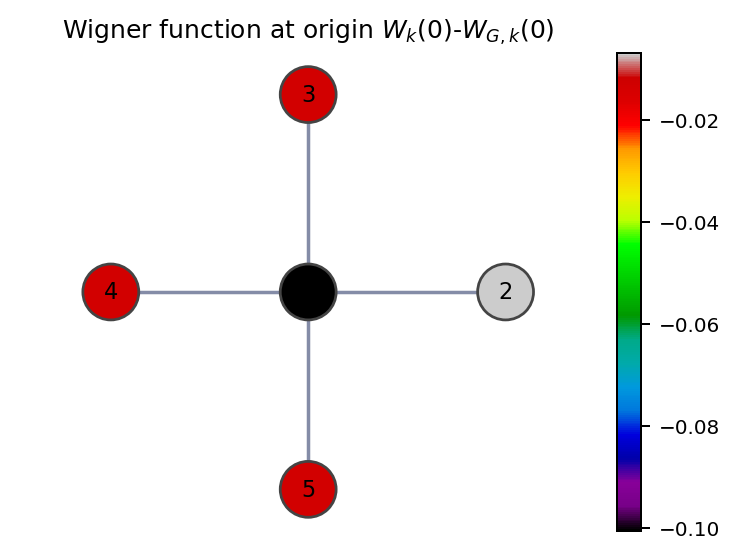

{0: (0.0, 0.0),
 1: (1.0, 0.0),
 2: (6.123233995736766e-17, 1.0),
 3: (-1.0, 1.2246467991473532e-16),
 4: (-1.8369701987210297e-16, -1.0)}

In [18]:
WG0_vals = nodewise_gaussian_wigner_origin(V, m)

pos = plot_graph_from_matrix(
    Adj,
    node_values=WG0_vals,
    cmap="nipy_spectral",
    pos=pos,
    draw_labels=True,
    vmin=np.min(W0_vals),
    title=r"Gaussian Wigner function at origin $W_{G,k}(0)$"
)
plot_graph_from_matrix(
    Adj,
    node_values=W0_vals,
    title="Wigner function at origin $W_k(0)$",
    pos=pos,
    cmap="nipy_spectral", 
    vmin=np.min(W0_vals),
    draw_labels=True
)
plot_graph_from_matrix(
    Adj,
    node_values=W0_vals-WG0_vals,
    title="Wigner function at origin $W_k(0)$-$W_{G,k}(0)$",
    pos=pos,
    cmap="nipy_spectral", 
    vmin=np.min(W0_vals),
    draw_labels=True
)

In [19]:
# Common Wigner plotting utilities.
# Run this cell once, then use the output cell below.

from matplotlib.colors import Normalize, TwoSlopeNorm
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Gaussian Wigner function을 그리기 위해 범위를 지정하고, Gaussian Wigner function 값 계산
def gaussian_wigner_grid(V_k, xlim=10, n=100):
    x = np.linspace(-xlim, xlim, n)
    p = np.linspace(-xlim, xlim, n)
    X, P = np.meshgrid(x, p)
    R = np.stack([X, P], axis=-1)

    V_inv = np.linalg.inv(V_k)
    det_V = np.linalg.det(V_k)
    quad = np.einsum("...i,ij,...j->...", R, V_inv, R)
    W = np.exp(-0.5 * quad) / ((2 * np.pi) * np.sqrt(det_V))

    return X, P, W

# Photon-subtracted Wigner function을 그리기 범위를 지정하고 Photon-subtracted Wigner function 값 계산
def photon_subtracted_wigner_grid(V_k, A_k, xlim=10, n=100):
    X, P, W_gauss = gaussian_wigner_grid(V_k, xlim=xlim, n=n)
    R = np.stack([X, P], axis=-1)

    V_inv = np.linalg.inv(V_k)
    B = V_inv @ A_k @ V_inv
    quad_A = np.einsum("...i,ij,...j->...", R, B, R)
    trace_A = np.trace(V_inv @ A_k)
    W_minus = 0.5 * (quad_A - trace_A + 2) * W_gauss

    return X, P, W_minus

# 앞에서 구한 V와 A_minus 행렬을 single node로 reduce한 후, 해당 x,p,W를 위의 함수로 구한 후 위에서 지정한 범위내에서 최대, 최소를 계산하여 zlim으로 반환하는 함수
def node_wigner_data(V, A, node, m, xlim=10, n=100):
    V_k, A_k, _ = reduced_matrices(V, A, subset=[node], m=m)
    X, P, W_before = gaussian_wigner_grid(V_k, xlim=xlim, n=n)
    _, _, W_after = photon_subtracted_wigner_grid(V_k, A_k, xlim=xlim, n=n)

    z_min = min(np.min(W_before), np.min(W_after))
    z_max = max(np.max(W_before), np.max(W_after))
    z_pad = 0.05 * (z_max - z_min) if not np.isclose(z_min, z_max) else 1e-3
    zlim = (z_min - z_pad, z_max + z_pad)

    return X, P, W_before, W_after, zlim

# Wigner function의 색상 범위를 W의 최소값과 최대값에 따라 자동으로 조절하는 norm 객체를 반환하는 함수, TwoSlopeNorm은 W가 음수와 양수 모두를 포함할 때 0을 중심으로 색상을 조절하는 데 사용되고, Normalize는 W가 모두 양수이거나 모두 음수일 때 사용된다.
# TwoSlopeNorm가 하는 일은 양수일 때와 음수일 때 색상이 다른 그라데이션, Normalize는 양수이거나 음수일 때 중심값 기준으로 다른 그라데이션이 되게 설정해줌
def wigner_color_norm(W):
    w_min = np.min(W)
    w_max = np.max(W)

    if w_min < 0 < w_max:
        return TwoSlopeNorm(vmin=w_min, vcenter=0, vmax=w_max)

    return Normalize(vmin=w_min, vmax=w_max)

# Wigner function을 3D surface plot으로 그리는 함수, zero_plane이 True이면 W=0인 평면도 같이 그려준다.
# 함수 설명 ax: 3D plot이 그려질 matplotlib 축 객체, ax.plot_surface라는 메소드는 3D surface plot을 그리는 메소드이며, ax.countour는 등고선을 그리는 메소드이다. 
# 나중에 plt.figure로 figure 객체를 만들고, fig.add_subplot(1, 2, 1, projection="3d")같이 3D 축 객체를 따로 정의해서 만들고 이 함수를 호출하면 된다.
# 이후 이 객체(3D_subfigure)에 대해서 제목, 축 레이블, 시점 등을 설정할 수 있다. set_zlim은 혹여나 W의 범위가 너무 크거나 작아서 그래프가 잘 안보이는 경우 z축 범위를 수동으로 설정할 때 사용한다.

def plot_wigner_surface_static(ax, X, P, W, title, cmap="inferno", zlim=None, zero_plane=True):
    norm = wigner_color_norm(W)
    ax.plot_surface(X, P, W, cmap=cmap, norm=norm, linewidth=0, antialiased=True)

    if zero_plane and zlim is not None and zlim[0] < 0 < zlim[1]:
        Z0 = np.zeros_like(W)
        ax.plot_surface(X, P, Z0, color="black", alpha=0.12, linewidth=0, shade=False)
        ax.contour(X, P, W, levels=[0], zdir="z", offset=0, colors="black", linewidths=1.1)

    ax.contour(X, P, W, zdir="z", offset=np.min(W), cmap=cmap, linewidths=0.7)
    ax.set_title(f"{title}\nmin={np.min(W):.3g}, max={np.max(W):.3g}")
    ax.set_xlabel("x")
    ax.set_ylabel("p")
    ax.set_zlabel("W")
    ax.view_init(elev=24, azim=-38) # 시점 설정, elev은 z축에 대한 높이, azim은 x축에 대한 회전 각도

    if zlim is not None:
        ax.set_zlim(*zlim)


# 위에서 wigner_surface를 matplotlib으로는 그리는 함수를 호출하는 함수이다. 이때 figure안에 두 sub 객체를 만들어 왼쪽은 Gaussian Wigner function, 오른쪽은 photon-subtracted Wigner function이 그려지게 된다. 
# cmap_before와 cmap_after는 각각 Gaussian Wigner function과 photon-subtracted Wigner function의 색상 맵을 지정하는 인자이다. (가우시안은 항상 양수이니 viridis, photon-subtracted는 양수/음수 모두 나올 수 있으니 coolwarm같은 colormap을 사용)


def plot_node_wigner_3d_static(V, A, node, m, xlim=10, n=100, cmap_before="viridis", cmap_after="coolwarm"):
    X, P, W_before, W_after, zlim = node_wigner_data(V, A, node, m, xlim=xlim, n=n)

    fig = plt.figure(figsize=(14, 5.2))
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")

    plot_wigner_surface_static(ax1, X, P, W_before, f"node {node}: before subtraction", cmap=cmap_before, zlim=zlim, zero_plane=False)
    plot_wigner_surface_static(ax2, X, P, W_after, f"node {node}: after subtraction", cmap=cmap_after, zlim=zlim)

    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.02, top=0.88, wspace=0.04)
    plt.show()

# 위와는 다르게 정적이지 않고 직접 그래프를 회전 시키면서 볼 수 있게 plotly로 그리는 함수이다.
# plotly의 make_subplots 함수를 사용하여 figure 안에 2개의 subplot을 만들고, 각각에 go.Surface를 사용하여 Wigner function의 surface plot을 그린다.(기본 작동원리는 matplotlib처럼 x,y,z축 데이터를 받아 그림)
# 차이점은 figure객체를 정의하는 방식과 plot_surface 대신 go.Surface를 사용한다는 점이다.(go.Surface는 plotly에서 3D surface plot을 그리는 메소드이다.)
# 자세한건 plotly 공식문서의 go.Surface와 make_subplots 설명 참고: https://plotly.com/python/3d-surface-plots/ , https://plotly.com/python/subplots/
def plot_node_wigner_3d_interactive(V, A, node, m, xlim=10, n=100):
    X, P, W_before, W_after, _ = node_wigner_data(V, A, node, m, xlim=xlim, n=n)

    after_abs = max(abs(np.min(W_after)), abs(np.max(W_after)))
    if np.isclose(after_abs, 0):
        after_abs = 1

    fig = make_subplots(
        rows=1,
        cols=2,
        specs=[[{"type": "surface"}, {"type": "surface"}]],
        subplot_titles=(
            f"node {node}: before subtraction<br>min={np.min(W_before):.3g}, max={np.max(W_before):.3g}",
            f"node {node}: after subtraction<br>min={np.min(W_after):.3g}, max={np.max(W_after):.3g}"
        ),
        horizontal_spacing=0.02
    )

    fig.add_trace(
        go.Surface(x=X, y=P, z=W_before, colorscale="Viridis", showscale=False),
        row=1,
        col=1
    )

    fig.add_trace(
        go.Surface(
            x=X,
            y=P,
            z=W_after,
            colorscale="RdBu_r",
            cmin=-after_abs,
            cmax=after_abs,
            showscale=True,
            colorbar=dict(title="W", x=1.02, len=0.75)
        ),
        row=1,
        col=2
    )

    fig.add_trace(
        go.Surface(
            x=X,
            y=P,
            z=np.zeros_like(W_after),
            surfacecolor=np.zeros_like(W_after),
            colorscale=[[0, "black"], [1, "black"]],
            opacity=0.18,
            showscale=False,
            hoverinfo="skip"
        ),
        row=1,
        col=2
    )

    camera = dict(eye=dict(x=0.8, y=1.8, z=0.8))
    scene_style = dict(
        xaxis_title="x",
        yaxis_title="p",
        zaxis_title="W",
        camera=camera,
        aspectmode="cube"
    )

    fig.update_layout(
        width=1150,
        height=560,
        margin=dict(l=0, r=0, t=60, b=0),
        scene=scene_style,
        scene2=scene_style
    )

    fig.show()


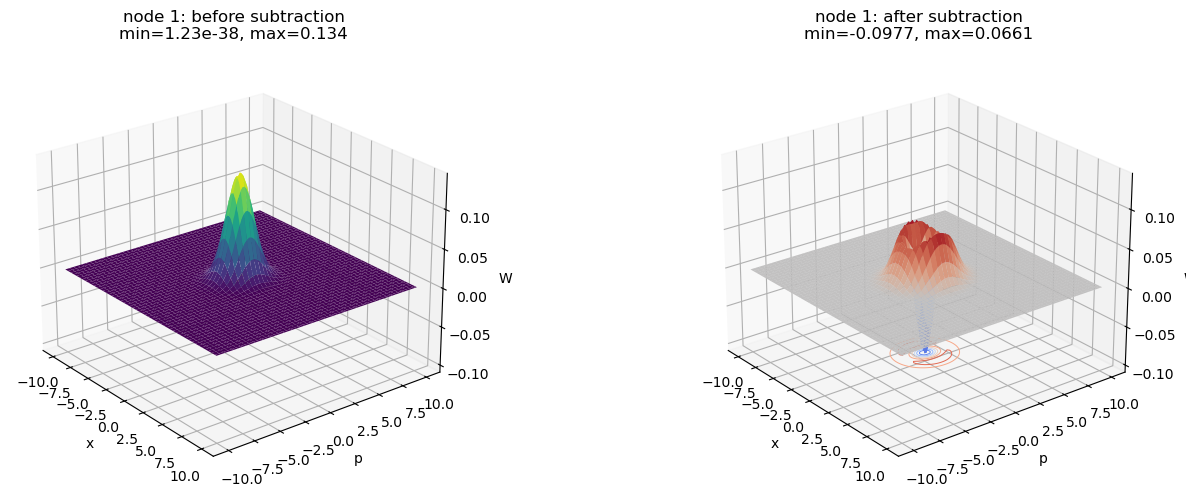

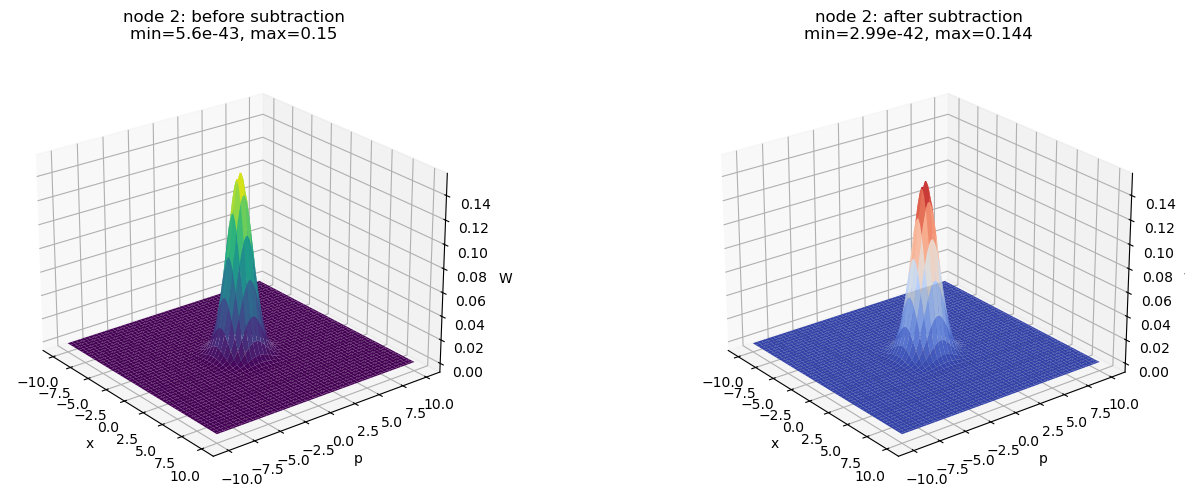

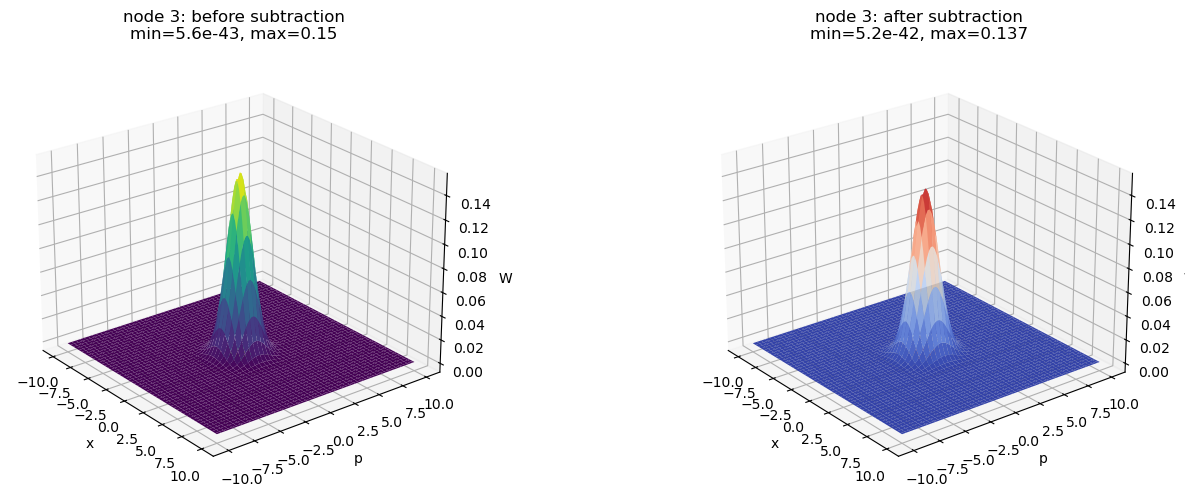

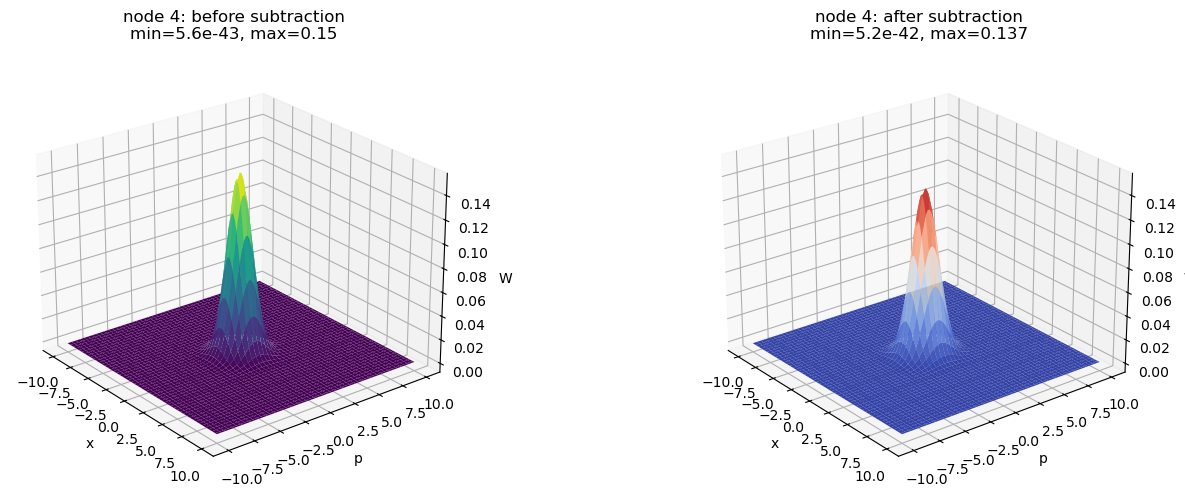

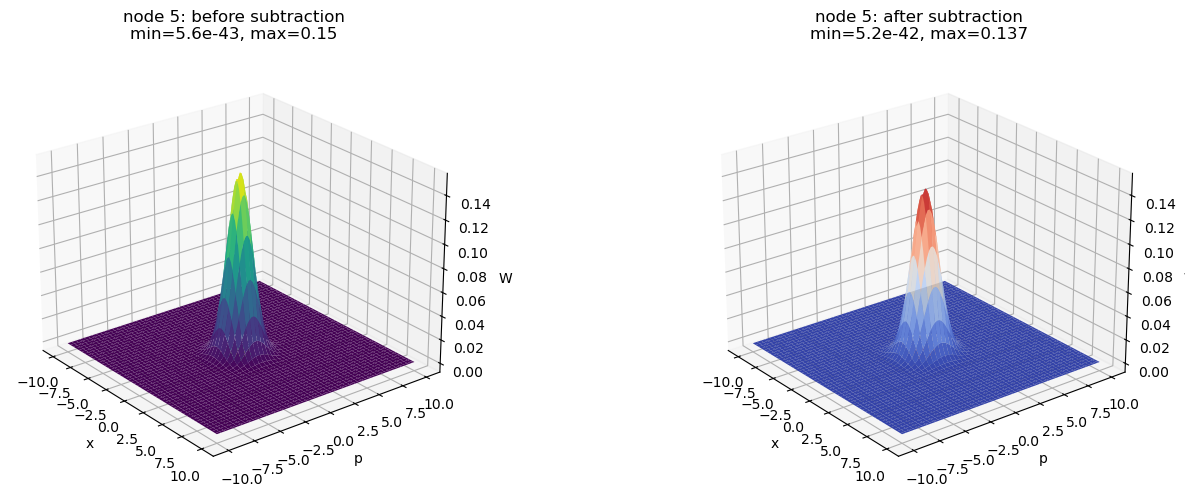

In [20]:

# 1부터 m까지의 노드에 대해, plot_static이 True이면 정적 3D plot을 그리고, plot_interactive이 True이면 인터랙티브 3D plot을 그린다. 
nodes_to_plot = range(1, m + 1)
plot_static = True
plot_interactive = False#True

# 노드별로 그리기 위해서 다음과 같이 정의
for node in nodes_to_plot:
    if plot_static:
        plot_node_wigner_3d_static(V, A_minus, node=node, m=m, xlim=10, n=100)

    if plot_interactive:
        plot_node_wigner_3d_interactive(V, A_minus, node=node, m=m, xlim=10, n=100)


## 3. Homodyne Measurement

####  3.1 Photon subtraction, and afterward, Neighborhood Deletion FeedFoward w/ x measurement(by HOMODYNE)

#####  Initial variable layer

In [21]:
# ============================================================
# 3.1.1 Initial variable layer
# Case a: photon subtraction 먼저 한 경우
# Corrected version: graph-nullifier feedforward
#
# IMPORTANT:
#   Use K_Gamma = [[0], [Gamma_RH]]
#   Do NOT use K_cm = V_qRxH V_xHxH^{-1}
#
# Existing variables:
#   m        : number of modes
#   V        : full Gaussian envelope matrix
#   A_minus  : full non-Gaussian correction matrix after photon subtraction
#   sub_node : photon-subtracted node label, 1-based
#   Gamma_eff or Adj : graph adjacency matrix
#
# ordering:
#   q = (x1,...,xm,p1,...,pm)
# ============================================================

import numpy as np

# ------------------------------------------------------------
# User input
# ------------------------------------------------------------
H = [3,4,5]          # deleted / homodyne-measured nodes, 1-based
j = sub_node           # photon-subtracted node, 1-based

# ------------------------------------------------------------
# Use already-defined A_minus
# ------------------------------------------------------------
A_j = A_minus

# ------------------------------------------------------------
# Choose graph adjacency matrix
# ------------------------------------------------------------
if "Gamma_eff" in globals():
    Gamma = Gamma_eff
elif "Adj" in globals():
    Gamma = Adj
else:
    raise NameError("Need graph adjacency matrix: Gamma_eff or Adj")

# ------------------------------------------------------------
# Convert to 0-based node indices
# ------------------------------------------------------------
H0 = np.array([h - 1 for h in H], dtype=int)
j0 = j - 1

R0 = np.array([n for n in range(m) if n not in H0], dtype=int)

r = len(R0)
h = len(H0)

print("H =", list(H0 + 1))
print("R =", list(R0 + 1))
print("photon-subtracted node j =", j)

# ------------------------------------------------------------
# Quadrature indices
# ordering: q = (x1,...,xm,p1,...,pm)
# ------------------------------------------------------------
xR_idx = R0
pR_idx = R0 + m
qR_idx = np.r_[xR_idx, pR_idx]

xH_idx = H0
pH_idx = H0 + m

# ------------------------------------------------------------
# Graph-nullifier feedforward gain
#
# Initial nullifier:
#   delta_R = p_R - Gamma_RR x_R - Gamma_RH x_H
#
# Feedforward:
#   p_R^ff = p_R - Gamma_RH x_H
#
# Therefore:
#   q_R^ff = q_R - K_Gamma x_H
#
# where:
#   K_Gamma = [ 0       ]
#             [ Gamma_RH]
# ------------------------------------------------------------
Gamma_RH = Gamma[np.ix_(R0, H0)]

K_Gamma = np.vstack([
    np.zeros((r, h)),
    Gamma_RH
])

print("Gamma_RH =")
print(Gamma_RH)
print("K_Gamma shape =", K_Gamma.shape)

# ------------------------------------------------------------
# Extract V blocks
# ------------------------------------------------------------
V_qRqR = V[np.ix_(qR_idx, qR_idx)]
V_qRxH = V[np.ix_(qR_idx, xH_idx)]
V_xHqR = V[np.ix_(xH_idx, qR_idx)]
V_xHxH = V[np.ix_(xH_idx, xH_idx)]

# ------------------------------------------------------------
# Correct Gaussian envelope after graph feedforward
#
# V_R_ff = L_Gamma V L_Gamma^T
#
# with
#   L_Gamma = ( I  -K_Gamma  0 )
#
# Block form:
#   V_R_ff
#   = V_qRqR
#     - K_Gamma V_xHqR
#     - V_qRxH K_Gamma^T
#     + K_Gamma V_xHxH K_Gamma^T
# ------------------------------------------------------------
V_R_ff = (
    V_qRqR
    - K_Gamma @ V_xHqR
    - V_qRxH @ K_Gamma.T
    + K_Gamma @ V_xHxH @ K_Gamma.T
)

V_R_ff = 0.5 * (V_R_ff + V_R_ff.T)

# ------------------------------------------------------------
# Extract A_minus blocks
# ------------------------------------------------------------
A_qRqR = A_j[np.ix_(qR_idx, qR_idx)]
A_qRxH = A_j[np.ix_(qR_idx, xH_idx)]
A_xHqR = A_j[np.ix_(xH_idx, qR_idx)]
A_xHxH = A_j[np.ix_(xH_idx, xH_idx)]

# ------------------------------------------------------------
# Correct non-Gaussian correction after graph feedforward
#
# A_R_ff = L_Gamma A_minus L_Gamma^T
# ------------------------------------------------------------
A_R_ff = (
    A_qRqR
    - K_Gamma @ A_xHqR
    - A_qRxH @ K_Gamma.T
    + K_Gamma @ A_xHxH @ K_Gamma.T
)

A_R_ff = 0.5 * (A_R_ff + A_R_ff.T)

# ------------------------------------------------------------
# Actual second moment of the final non-Gaussian state
# ------------------------------------------------------------
V_actual_R_ff = V_R_ff + A_R_ff

# ------------------------------------------------------------
# Target node local index
# If photon-subtracted node is deleted, j_local is None.
# ------------------------------------------------------------
if j0 in R0:
    j_local = int(np.where(R0 == j0)[0][0])
    print("target node remains.")
    print("target original node =", j)
    print("target local node =", j_local + 1)
else:
    j_local = None
    print("target photon-subtracted node is deleted.")

# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------
print("V_R_ff shape =", V_R_ff.shape)
print("A_R_ff shape =", A_R_ff.shape)
print("V_actual_R_ff shape =", V_actual_R_ff.shape)

print("V_R_ff symmetric check:",
      bool(np.linalg.norm(V_R_ff - V_R_ff.T) < 1e-10))

print("A_R_ff symmetric check:",
      bool(np.linalg.norm(A_R_ff - A_R_ff.T) < 1e-10))

print("V_actual_R_ff symmetric check:",
      bool(np.linalg.norm(V_actual_R_ff - V_actual_R_ff.T) < 1e-10))

H = [3, 4, 5]
R = [1, 2]
photon-subtracted node j = 2
Gamma_RH =
[[0.23584705 0.23584705 0.23584705]
 [0.         0.         0.        ]]
K_Gamma shape = (4, 3)
target node remains.
target original node = 2
target local node = 2
V_R_ff shape = (4, 4)
A_R_ff shape = (4, 4)
V_actual_R_ff shape = (4, 4)
V_R_ff symmetric check: True
A_R_ff symmetric check: True
V_actual_R_ff symmetric check: True


In [22]:
def make_reduced_pos_and_labels(pos_full, R0, label_base=1):
    """
    pos_full : original graph position dict
               예: {0:(...), 1:(...), ..., 5:(...)}
    R0       : remaining nodes in 0-based original indexing
               예: original nodes [2,5,6]이면 R0 = [1,4,5]
    label_base : display label offset. 1이면 원래 node label을 1-based로 표시.

    Returns
    -------
    pos_R    : reduced graph position dict
               keys = 0,1,2,... local reduced indices
    labels_R : reduced graph labels
               keys = 0,1,2,..., values = original node labels
    """
    R0 = list(R0)

    pos_R = {
        local_idx: pos_full[int(orig_idx)]
        for local_idx, orig_idx in enumerate(R0)
    }

    labels_R = {
        local_idx: str(int(orig_idx) + label_base)
        for local_idx, orig_idx in enumerate(R0)
    }

    return pos_R, labels_R

##### A<sub>R</sub><sup>ff</sup>, V<sub>R</sub><sup>ff</sup> matrix layer

Deleted nodes H = [3, 4, 5]
Remaining nodes R = [1, 2]
photon-subtracted node j = 2
Number of remaining modes = 2
V_R_ff shape = (4, 4)
A_R_ff shape = (4, 4)
V_actual_R_ff shape = (4, 4)
V_R_ff symmetric check: True
A_R_ff symmetric check: True
V_actual_R_ff symmetric check: True
V_R^{ff} = 


,1,2,3,4
1,1.047,0.000,0.000,0.314
2,0.000,1.047,0.314,0.000
3,0.000,0.314,1.062,0.000
4,0.314,0.000,0.000,1.049


(A_g^-)_R^{ff} = 


,1,2,3,4
1,2.048,0.000,0.000,0.321
2,0.000,0.046,0.307,0.000
3,0.000,0.307,2.048,0.000
4,0.321,0.000,0.000,0.050


V_actual,R^{ff} = V_R^{ff} + (A_g^-)_R^{ff} = 


,1,2,3,4
1,3.095,0.000,0.000,0.635
2,0.000,1.093,0.621,0.000
3,0.000,0.621,3.110,0.000
4,0.635,0.000,0.000,1.100


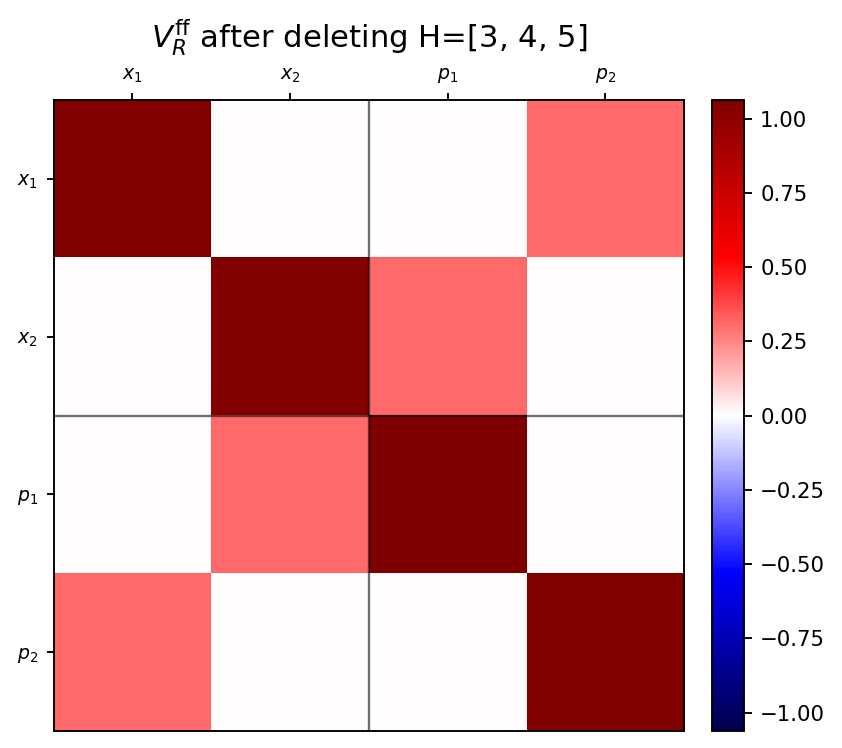

vmin=-1.06, vmax=1.06


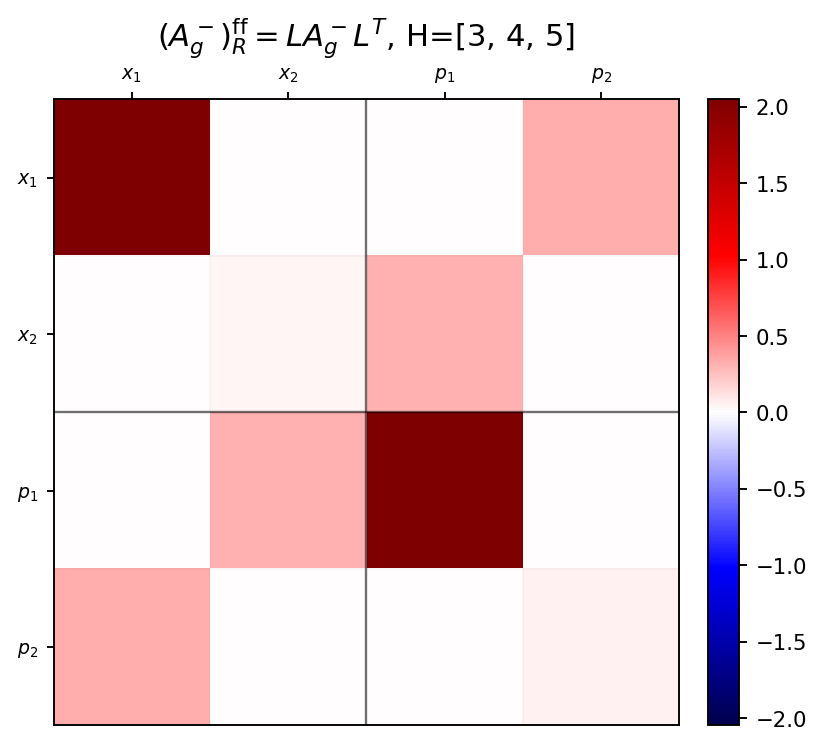

vmin=-2.05, vmax=2.05


In [23]:
# ============================================================
# 3.1.2 A_R, V_R matrix layer
# Case a: photon subtraction 먼저 한 경우
#
# Inputs from 3.1.1:
#   V_R_ff
#   A_R_ff
#   V_actual_R_ff
#   R0
#   H
#   j
# ============================================================

# -----------------------------
# Basic labels
# -----------------------------
R_labels = list(R0 + 1)  # 1-based node labels for display
r = len(R_labels)

print("Deleted nodes H =", H)
print("Remaining nodes R =", R_labels)
print("photon-subtracted node j =", j)
print("Number of remaining modes =", r)

# -----------------------------
# Matrix sanity checks
# -----------------------------
print("V_R_ff shape =", V_R_ff.shape)
print("A_R_ff shape =", A_R_ff.shape)
print("V_actual_R_ff shape =", V_actual_R_ff.shape)

print("V_R_ff symmetric check:", np.linalg.norm(V_R_ff - V_R_ff.T) < 1e-10)
print("A_R_ff symmetric check:", np.linalg.norm(A_R_ff - A_R_ff.T) < 1e-10)
print("V_actual_R_ff symmetric check:", np.linalg.norm(V_actual_R_ff - V_actual_R_ff.T) < 1e-10)

# -----------------------------
# Optional: print matrices numerically
# -----------------------------
show_mat(V_R_ff, name=r"V_R^{ff} = ")
show_mat(A_R_ff, name=r"(A_g^-)_R^{ff} = ")
show_mat(V_actual_R_ff, name=r"V_actual,R^{ff} = V_R^{ff} + (A_g^-)_R^{ff} = ")

# -----------------------------
# Draw Gaussian envelope covariance
# Mattia-style V matrix
# -----------------------------
# draw_phase_matrix(
#     V_R_ff,
#     title=rf"$V_R^{{\rm ff}}$ after deleting H={H}",
#     positive=False,
#     cmap="seismic",
#     tick_step=1,
#     figsize=(5, 4.5),
#     grid=True
# )

# -----------------------------
# Draw non-Gaussian correction matrix
# A_R_ff = L A_minus L^T
# -----------------------------
# draw_phase_matrix(
#     A_R_ff,
#     title=rf"$(A_g^-)_R^{{\rm ff}} = L A_g^- L^T$, H={H}",
#     positive=False,
#     cmap="seismic",
#     tick_step=1,
#     figsize=(5, 4.5),
#     grid=True
# )

# -----------------------------
# Draw actual covariance
# This is not Mattia's V.
# This is the actual second moment matrix of the non-Gaussian state.
# -----------------------------
# draw_phase_matrix(
#     V_actual_R_ff,
#     title=rf"$V_{{\rm actual,R}}^{{\rm ff}} = V_R^{{\rm ff}} + (A_g^-)_R^{{\rm ff}}$",
#     positive=False,
#     cmap="seismic",
#     tick_step=1,
#     figsize=(5, 4.5),
#     grid=True
# )



# mode_labels로 원래 노드 번호(1-based)를 전달해서 라벨을 x2,x5,x6 / p2,p5,p6로 표시
draw_phase_matrix(
    V_R_ff,
    title=rf"$V_R^{{\rm ff}}$ after deleting H={H}",
    mode_labels=R_labels,
    positive=False,
    cmap="seismic",
    tick_step=1,
    figsize=(5, 4.5),
    grid=True,
)
draw_phase_matrix(
    A_R_ff,
    title=rf"$(A_g^-)_R^{{\rm ff}} = L A_g^- L^T$, H={H}",
    mode_labels=R_labels,
    positive=False,
    cmap="seismic",
    tick_step=1,
    figsize=(5, 4.5),
    grid=True,
)
# draw_phase_matrix(
#     V_actual_R_ff,
#     title=rf"$V_{{\rm actual,R}}^{{\rm ff}} = V_R^{{\rm ff}} + (A_g^-)_R^{{\rm ff}}$",
#     mode_labels=R_labels,
#     positive=False,
#     cmap="seismic",
#     tick_step=1,
#     figsize=(5, 4.5),
#     grid=True,
# )

In [24]:
def estimate_effective_adjacency(V_R_ff, tol=1e-12):
    """
    Input:
        V_R_ff: 2r x 2r matrix in ordering (x_R, p_R)

    Returns:
        Gamma_px: adjacency estimate from nullifier delta = p - Gamma x
        V_delta_px: nullifier covariance for delta = p - Gamma x
        Gamma_xp: optional estimate from delta = x - Gamma p
        V_delta_xp: optional diagnostic
    """
    N = V_R_ff.shape[0]
    assert N % 2 == 0, "V_R_ff must be 2r x 2r"
    r = N // 2

    V_xx = V_R_ff[:r, :r]
    V_xp = V_R_ff[:r, r:]
    V_px = V_R_ff[r:, :r]
    V_pp = V_R_ff[r:, r:]

    pinv_xx = np.linalg.pinv(V_xx, rcond=tol)
    pinv_pp = np.linalg.pinv(V_pp, rcond=tol)

    # Main CV graph convention: delta = p - Gamma x
    Gamma_px = V_px @ pinv_xx

    V_delta_px = (
        V_pp
        - Gamma_px @ V_xp
        - V_px @ Gamma_px.T
        + Gamma_px @ V_xx @ Gamma_px.T
    )
    V_delta_px = 0.5 * (V_delta_px + V_delta_px.T)

    # Optional diagnostic only: delta = x - Gamma p
    Gamma_xp = V_xp @ pinv_pp

    V_delta_xp = (
        V_xx
        - Gamma_xp @ V_px
        - V_xp @ Gamma_xp.T
        + Gamma_xp @ V_pp @ Gamma_xp.T
    )
    V_delta_xp = 0.5 * (V_delta_xp + V_delta_xp.T)

    return Gamma_px, np.diag(V_delta_px), V_delta_px, Gamma_xp, np.diag(V_delta_xp), V_delta_xp

Main nullifier: p - Gamma x
nullifier variances: [0.96792128 0.95499259]
Diagnostic alternative: x - Gamma p
alternative nullifier variances: [0.9530761  0.95422091]


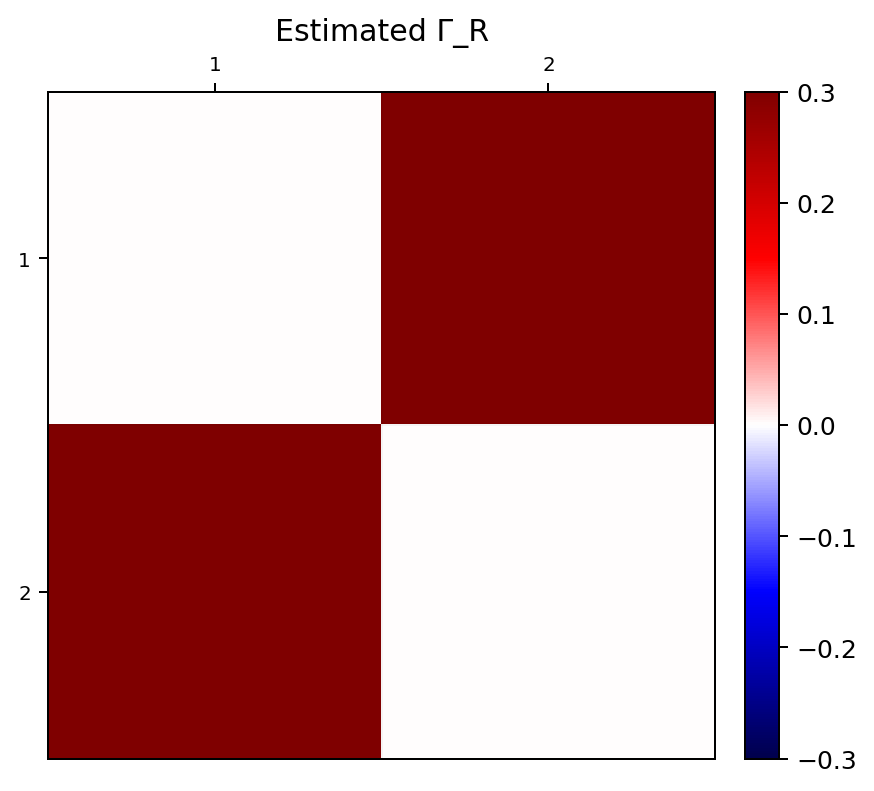

{0: (0.0, 0.0), 1: (1.0, 0.0)}
{0: '1', 1: '2'}


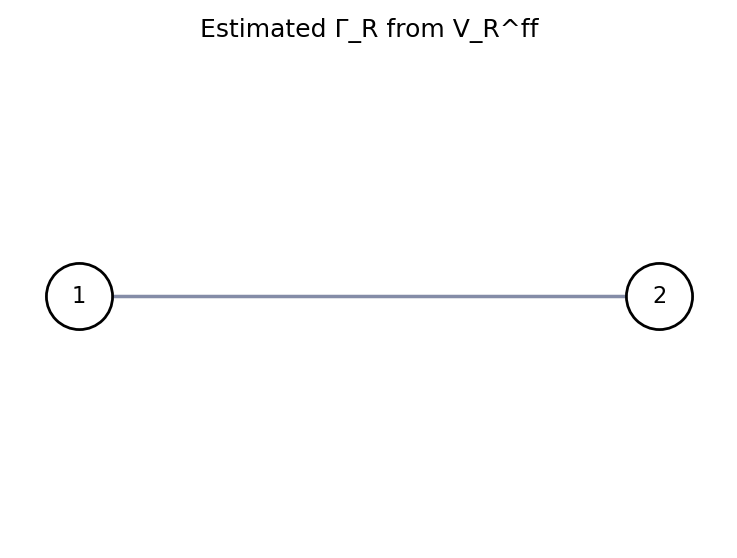

{0: (0.0, 0.0), 1: (1.0, 0.0)}

In [25]:
Gamma_R, nullvar_R, Vdelta_R, Gamma_alt, nullvar_alt, Vdelta_alt = estimate_effective_adjacency(V_R_ff)

print("Main nullifier: p - Gamma x")
print("nullifier variances:", nullvar_R)

print("Diagnostic alternative: x - Gamma p")
print("alternative nullifier variances:", nullvar_alt)

draw_mat(Gamma_R, title="Estimated Γ_R", cmap="seismic", label=False, digits=2, grid=True)
# node 색상에 nullifier variance 표시, 라벨=2,5,6
pos_R, labels_R = make_reduced_pos_and_labels(pos, R0)

print(pos_R)
print(labels_R)
plot_graph_from_matrix(
    Gamma_R,
    #node_values=nullvar_R,
    title="Estimated Γ_R from V_R^ff",
    pos=pos_R,
    draw_labels=True,
    labels=labels_R
)

##### graph layer

R original labels = [1, 2]
Kex_x = [-1.31354966 -0.00533431]
Kex_p = [-1.30088179 -0.00628064]


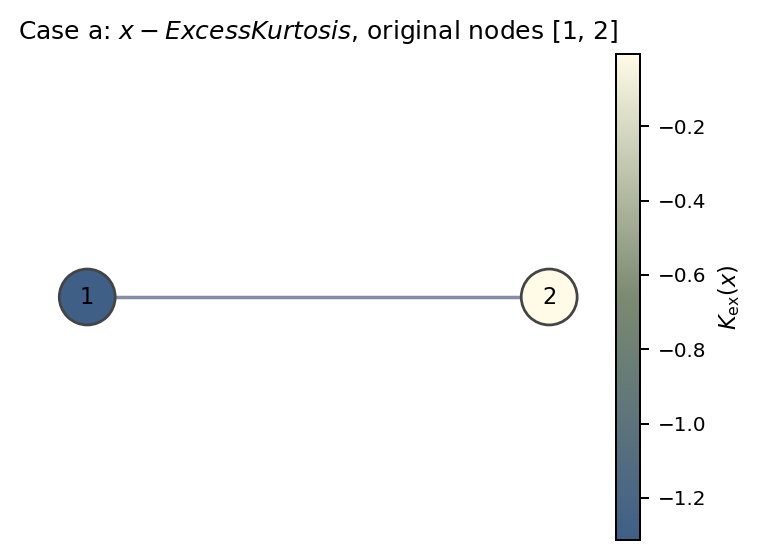

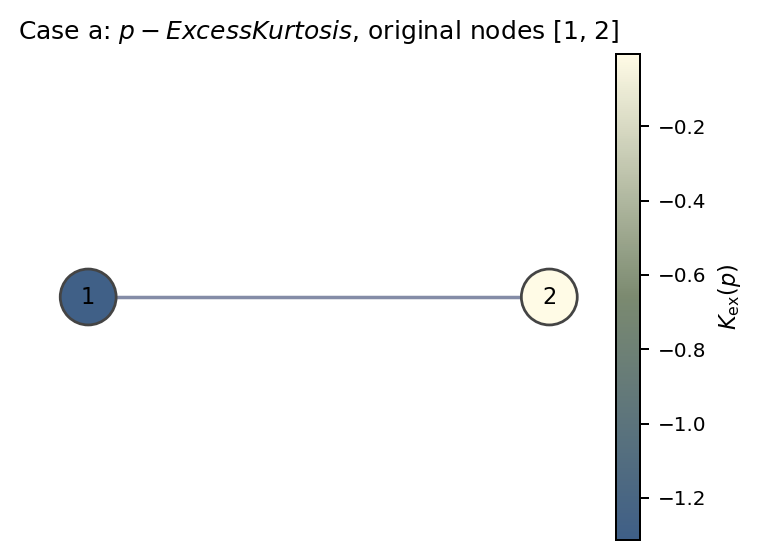

In [26]:
# ============================================================
# 3.1.3 Graph layer - kurtosis reflected graph
# Case a: photon subtraction 먼저 한 경우
#
# Required variables:
#   V_R_ff, A_R_ff, R0, Gamma_R, pos
#   plot_graph_from_matrix(..., labels=labels_R) 로 수정되어 있어야 함
# ============================================================

r = len(R0)

# ------------------------------------------------------------
# 1. Node-wise excess kurtosis
# ------------------------------------------------------------
Kex_x = np.zeros(r)
Kex_p = np.zeros(r)

for k in range(r):
    x_idx = k
    p_idx = k + r

    # x quadrature
    v_x = V_R_ff[x_idx, x_idx]
    a_x = A_R_ff[x_idx, x_idx]
    Kex_x[k] = -3 * a_x**2 / (v_x + a_x)**2

    # p quadrature
    v_p = V_R_ff[p_idx, p_idx]
    a_p = A_R_ff[p_idx, p_idx]
    Kex_p[k] = -3 * a_p**2 / (v_p + a_p)**2

print("R original labels =", list(R0 + 1))
print("Kex_x =", Kex_x)
print("Kex_p =", Kex_p)

# ------------------------------------------------------------
# 2. Reduced graph position and labels
#    Gamma_R node index: 0,1,2,...
#    display label: original node number, e.g. 2,5,6
# ------------------------------------------------------------
pos_R = {
    local_idx: pos[int(original_idx)]
    for local_idx, original_idx in enumerate(R0)
}

labels_R = {
    local_idx: int(original_idx) + 1
    for local_idx, original_idx in enumerate(R0)
}

# common color scale for x and p kurtosis
vmin_K = min(np.nanmin(Kex_x), np.nanmin(Kex_p))
vmax_K = max(np.nanmax(Kex_x), np.nanmax(Kex_p))

# ------------------------------------------------------------
# 3. Draw graph colored by x-quadrature excess kurtosis
# ------------------------------------------------------------
pos_R = plot_graph_from_matrix(
    Gamma_R,
    node_values=Kex_x,
    title=rf"Case a: $x-Excess Kurtosis$, original nodes {list(R0 + 1)}",
    pos=pos_R,
    labels=labels_R,
    draw_labels=True,
    cmap=blue,
    vmin=vmin_K,
    vmax=vmax_K,
    colorbar_label=r"$K_{\rm ex}(x)$"
)

# ------------------------------------------------------------
# 4. Draw graph colored by p-quadrature excess kurtosis
# ------------------------------------------------------------
pos_R = plot_graph_from_matrix(
    Gamma_R,
    node_values=Kex_p,
    title=rf"Case a: $p-Excess Kurtosis$, original nodes {list(R0 + 1)}",
    pos=pos_R,
    labels=labels_R,
    draw_labels=True,
    cmap=blue,
    vmin=vmin_K,
    vmax=vmax_K,
    colorbar_label=r"$K_{\rm ex}(p)$"
)

node local 1, original 1
V1 =
[[1.04712855 0.        ]
 [0.         1.06216285]]
A1 =
[[2.04815835 0.        ]
 [0.         2.04815835]]
Tr(V^-1 A) = 3.8842663675944813
W(0) condition Tr>2 ? True
min W = -0.14191989670301097
max W = 0.06704595697215453
has negativity? True


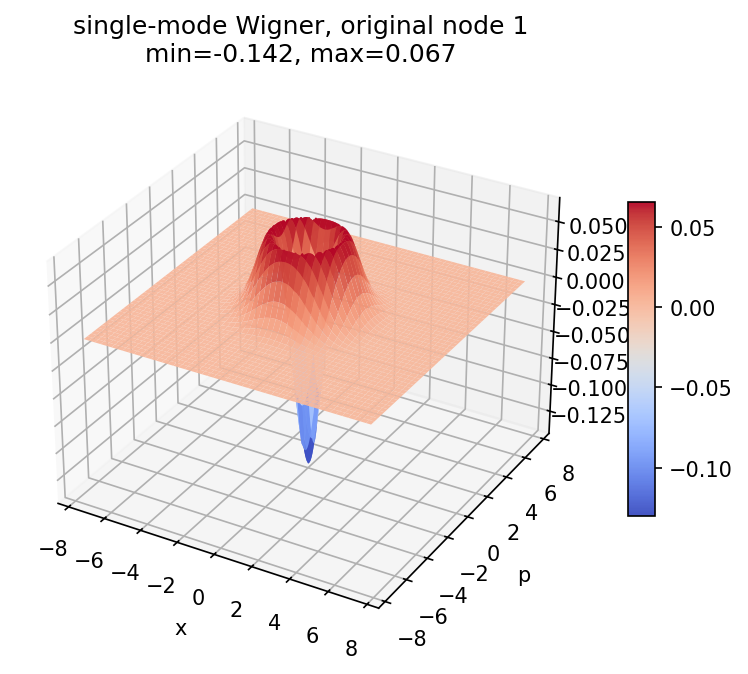

node local 2, original 2
V1 =
[[1.04712855 0.        ]
 [0.         1.04923416]]
A1 =
[[0.04609875 0.        ]
 [0.         0.05030996]]
Tr(V^-1 A) = 0.091973187681893
W(0) condition Tr>2 ? False
min W = 2.56723613871027e-24
max W = 0.1447738995667047
has negativity? False


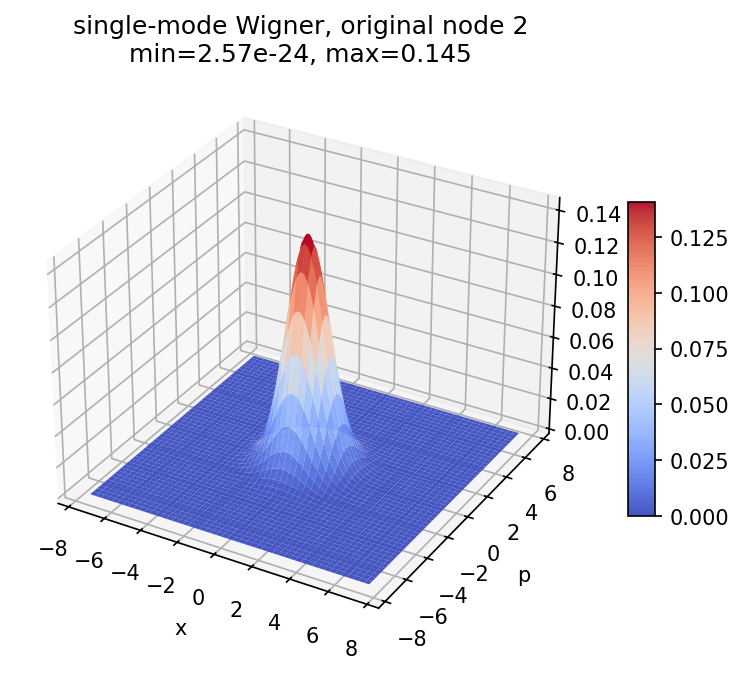

In [27]:
# ============================================================
# 3.1.3 Graph layer - single-mode Wigner function
# Case a: photon subtraction 먼저 한 경우
#
# Inputs:
#   V_R_ff, A_R_ff, R0
#
# ordering in reduced R-space:
#   q_R = (x_R, p_R)
# ============================================================

from mpl_toolkits.mplot3d import Axes3D

def single_mode_wigner_from_VA(V_eff, A_eff, node, m_eff, xlim=10, n=150):
    """
    node  : local node label, 1-based in reduced R-space
    m_eff : number of remaining modes
    V_eff : Gaussian envelope covariance
    A_eff : non-Gaussian correction matrix

    ordering = (x1,...,xm,p1,...,pm)
    """

    k = node - 1
    idx = [k, k + m_eff]

    V1 = V_eff[np.ix_(idx, idx)]
    A1 = A_eff[np.ix_(idx, idx)]

    Vinv = np.linalg.inv(V1)
    detV = np.linalg.det(V1)

    xs = np.linspace(-xlim, xlim, n)
    ps = np.linspace(-xlim, xlim, n)
    X, P = np.meshgrid(xs, ps)

    Z = np.stack([X, P], axis=-1)

    quad = np.einsum("...i,ij,...j->...", Z, Vinv, Z)

    tr_term = np.trace(Vinv @ A1)

    poly_quad = np.einsum(
        "...i,ij,...j->...",
        Z,
        Vinv @ A1 @ Vinv,
        Z
    )

    pref = 1 / (2 * np.pi * np.sqrt(detV))

    W = pref * np.exp(-0.5 * quad) * (
        1 - 0.5 * tr_term + 0.5 * poly_quad
    )

    return X, P, W, V1, A1


def plot_single_mode_wigner_static(V_eff, A_eff, node, m_eff, original_label=None, xlim=10, n=150):
    X, P, W, V1, A1 = single_mode_wigner_from_VA(
        V_eff, A_eff, node=node, m_eff=m_eff, xlim=xlim, n=n
    )

    label = node if original_label is None else original_label

    print(f"node local {node}, original {label}")
    print("V1 =")
    print(V1)
    print("A1 =")
    print(A1)
    print("Tr(V^-1 A) =", np.trace(np.linalg.inv(V1) @ A1))
    print("W(0) condition Tr>2 ?", np.trace(np.linalg.inv(V1) @ A1) > 2)
    print("min W =", np.min(W))
    print("max W =", np.max(W))
    print("has negativity?", np.min(W) < 0)

    fig = plt.figure(figsize=(6, 4.5), dpi=150)
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_surface(
        X, P, W,
        cmap="coolwarm",
        linewidth=0,
        antialiased=True,
        alpha=0.95
    )

    ax.set_title(
        rf"single-mode Wigner, original node {label}" + "\n"
        + rf"min={np.min(W):.3g}, max={np.max(W):.3g}"
    )
    ax.set_xlabel("x")
    ax.set_ylabel("p")
    ax.set_zlabel("W")

    fig.colorbar(surf, shrink=0.55, aspect=12)
    plt.tight_layout()
    plt.show()

    return X, P, W, V1, A1
R_labels = list(R0 + 1)
r = len(R_labels)

for local_node in range(1, r + 1):
    original_node = R_labels[local_node - 1]

    X, P, W, V1, A1 = plot_single_mode_wigner_static(
        V_R_ff,
        A_R_ff,
        node=local_node,
        m_eff=r,
        original_label=original_node,
        xlim=7.5,
        n=300
    )

In [28]:
# ============================================================
# Interactive single-mode Wigner plot
# Case a: photon subtraction 먼저 한 경우
#
# Inputs:
#   V_R_ff, A_R_ff, R0
#
# ordering:
#   q_R = (x_R, p_R)
# ============================================================

import plotly.graph_objects as go
import numpy as np

def single_mode_wigner_grid_from_VA(V_eff, A_eff, node, m_eff, xlim=10, n=150):
    """
    node  : local node label, 1-based in reduced R-space
    m_eff : number of remaining modes
    V_eff : Gaussian envelope matrix
    A_eff : non-Gaussian correction matrix

    ordering = (x1,...,xm,p1,...,pm)
    """

    k = node - 1
    idx = [k, k + m_eff]  # [x_k, p_k]

    V1 = V_eff[np.ix_(idx, idx)]
    A1 = A_eff[np.ix_(idx, idx)]

    Vinv = np.linalg.inv(V1)
    detV = np.linalg.det(V1)

    xs = np.linspace(-xlim, xlim, n)
    ps = np.linspace(-xlim, xlim, n)
    X, P = np.meshgrid(xs, ps)

    Z = np.stack([X, P], axis=-1)

    quad = np.einsum("...i,ij,...j->...", Z, Vinv, Z)

    tr_term = np.trace(Vinv @ A1)

    poly_quad = np.einsum(
        "...i,ij,...j->...",
        Z,
        Vinv @ A1 @ Vinv,
        Z
    )

    pref = 1 / (2 * np.pi * np.sqrt(detV))

    W = pref * np.exp(-0.5 * quad) * (
        1 - 0.5 * tr_term + 0.5 * poly_quad
    )

    return X, P, W, V1, A1


def plot_single_mode_wigner_interactive(
    V_eff,
    A_eff,
    node,
    m_eff,
    original_label=None,
    xlim=10,
    n=160,
):
    """
    Interactive 3D Wigner plot using Plotly.
    """

    X, P, W, V1, A1 = single_mode_wigner_grid_from_VA(
        V_eff,
        A_eff,
        node=node,
        m_eff=m_eff,
        xlim=xlim,
        n=n
    )

    label = node if original_label is None else original_label

    W_min = np.nanmin(W)
    W_max = np.nanmax(W)

    print(f"local node {node} -> original node {label}")
    print("V1 =")
    print(V1)
    print("A1 =")
    print(A1)
    print("Tr(V1^{-1} A1) =", np.trace(np.linalg.inv(V1) @ A1))
    print("W(0) negativity condition Tr > 2 ?",
          np.trace(np.linalg.inv(V1) @ A1) > 2)
    print("min W =", W_min)
    print("max W =", W_max)
    print("has negativity?", W_min < 0)

    fig = go.Figure(
        data=[
            go.Surface(
                x=X,
                y=P,
                z=W,
                colorscale="RdBu",
                reversescale=True,
                colorbar=dict(title="W"),
            )
        ]
    )

    fig.update_layout(
        title=(
            f"Single-mode Wigner, original node {label}<br>"
            f"min={W_min:.3g}, max={W_max:.3g}"
        ),
        scene=dict(
            xaxis_title="x",
            yaxis_title="p",
            zaxis_title="W",
            camera=dict(
                eye=dict(x=1.6, y=-1.8, z=1.2)
            ),
        ),
        width=750,
        height=600,
    )

    fig.show()

    return X, P, W, V1, A1

R_labels = list(R0 + 1)
r = len(R_labels)

for local_node in range(1, r + 1):
    original_node = R_labels[local_node - 1]

    X, P, W, V1, A1 = plot_single_mode_wigner_interactive(
        V_R_ff,
        A_R_ff,
        node=local_node,
        m_eff=r,
        original_label=original_node,
        xlim=10,
        n=160
    )

local node 1 -> original node 1
V1 =
[[1.04712855 0.        ]
 [0.         1.06216285]]
A1 =
[[2.04815835 0.        ]
 [0.         2.04815835]]
Tr(V1^{-1} A1) = 3.8842663675944813
W(0) negativity condition Tr > 2 ? True
min W = -0.14055191980794185
max W = 0.06698821072054978
has negativity? True


local node 2 -> original node 2
V1 =
[[1.04712855 0.        ]
 [0.         1.04923416]]
A1 =
[[0.04609875 0.        ]
 [0.         0.05030996]]
Tr(V1^{-1} A1) = 0.091973187681893
W(0) negativity condition Tr > 2 ? False
min W = 2.9910925052044615e-42
max W = 0.14433726890330734
has negativity? False


In [29]:
def fock01_fidelity_from_VA(V_k, A_k):
    """
    V_k, A_k: single-mode reduced matrices, shape (2,2)

    Returns:
        F0 = <0|rho|0>
        F1 = <1|rho|1>

    Convention:
        [x,p] = 2i
        vacuum covariance = I
    """

    V_k = np.asarray(V_k, dtype=float)
    A_k = np.asarray(A_k, dtype=float)

    if V_k.shape != (2, 2) or A_k.shape != (2, 2):
        raise ValueError(
            "V_k and A_k must be 2x2 single-mode matrices. "
            "Use reduced_matrices(..., subset=[node], ...)."
        )

    I2 = np.eye(2)

    M = np.linalg.inv(V_k)
    B = M @ A_k @ M
    c0 = 2.0 - np.trace(M @ A_k)

    K = M + I2
    Sigma = np.linalg.inv(K)

    I0 = 2 * np.pi / np.sqrt(np.linalg.det(K))
    C = 1.0 / (2 * np.pi * np.sqrt(np.linalg.det(V_k)))

    I_B = I0 * np.trace(B @ Sigma)
    I_I = I0 * np.trace(Sigma)

    I_BI = I0 * (
        np.trace(B @ Sigma) * np.trace(Sigma)
        + 2 * np.trace(B @ Sigma @ Sigma)
    )

    F0 = C * (I_B + c0 * I0)

    F1 = C * (
        I_BI
        - I_B
        + c0 * (I_I - I0)
    )

    return float(np.real_if_close(F0)), float(np.real_if_close(F1))

In [30]:
# ============================================================
# Single-photon fidelity after homodyne measurement + feed-forward
#
# Inputs:
#   V_R_ff, A_R_ff, R0
#
# R0:
#   remaining original node indices, 0-based
#
# reduced system ordering:
#   q_R = (x_R, p_R)
# ============================================================

R_labels = list(R0 + 1)   # original node labels
print("Remaining nodes R =", R_labels)
r = len(R_labels)         # number of remaining modes

F0_vals = []
F1_vals = []

for local_node in range(1, r + 1):
    original_node = R_labels[local_node - 1]

    # local_node 기준으로 single-mode reduced V,A 추출
    V_k, A_k, inds = reduced_matrices(
        V_R_ff,
        A_R_ff,
        subset=[local_node],
        m=r
    )

    F0, F1 = fock01_fidelity_from_VA(V_k, A_k)

    F0_vals.append(F0)
    F1_vals.append(F1)

    print(
        f"local node {local_node} -> original node {original_node}: "
        f"F0 = {F0:.6f}, F1 = {F1:.6f}, F0+F1 = {F0+F1:.6f}"
    )

F0_vals = np.array(F0_vals)
F1_vals = np.array(F1_vals)

df_F = pd.DataFrame({
    "local node": np.arange(1, r + 1),
    "original node": R_labels,
    "F0 = <0|rho|0>": F0_vals,
    "F1 = <1|rho|1>": F1_vals,
    "F0 + F1": F0_vals + F1_vals,
})

display(df_F)

print()
print("max F1 =", np.max(F1_vals))
print("max F1 original node =", R_labels[np.argmax(F1_vals)])




Remaining nodes R = [1, 2]
local node 1 -> original node 1: F0 = 0.003060, F1 = 0.944649, F0+F1 = 0.947709
local node 2 -> original node 2: F0 = 0.953495, F1 = 0.044870, F0+F1 = 0.998365


,local node,original node,F0 = <0|rho|0>,F1 = <1|rho|1>,F0 + F1
0,1,1,0.003060,0.944649,0.947709
1,2,2,0.953495,0.044870,0.998365



max F1 = 0.944648943190912
max F1 original node = 1


####  3.2 Neighborhood Deletion FeedFoward w/ x measurement(by HOMODYNE), and afterward, Photon subtraction 

#### Initial variable

In [31]:
# ============================================================
# 3.2.1 Initial variable layer
# Case b: HD+FF deletion 먼저, photon subtraction 나중
#
# Inputs from previous cells:
#   V_R_ff : Gaussian envelope after deletion
#   R0     : remaining original nodes, 0-based
#   sub_node or j : photon-subtracted original node label, 1-based
#
# ordering in reduced R-space:
#   q_R = (x1,...,xr,p1,...,pr)
# ============================================================

r = len(R0)
R_labels = list(R0 + 1)

# photon subtraction target
j = sub_node          # original node label, 1-based
j0 = j - 1            # 0-based original node index

if j0 not in R0:
    raise ValueError(f"subtraction node {j} is deleted. Remaining nodes are {R_labels}")

# reduced local index
j_local0 = np.where(R0 == j0)[0][0]     # 0-based local index
j_local = j_local0 + 1                  # 1-based local label

print("Case b: deletion -> photon subtraction")
print("Remaining original nodes R =", R_labels)
print("photon subtraction original node =", j)
print("reduced local node =", j_local)

# ------------------------------------------------------------
# Build reduced projector Pi_g_R
# node-local photon subtraction on reduced node j_local
# ------------------------------------------------------------
g_R = np.zeros(r)
g_R[j_local0] = 1.0

Pi_x_R = np.outer(g_R, g_R)

Pi_g_R = np.block([
    [Pi_x_R,              np.zeros((r, r))],
    [np.zeros((r, r)),    Pi_x_R]
])

print("Pi_g_R projector check:",
      bool(np.linalg.norm(Pi_g_R @ Pi_g_R - Pi_g_R) < 1e-10))

# ------------------------------------------------------------
# A_minus after deletion
# A_minus_post = 2 (V_R_ff - I) Pi_g_R (V_R_ff - I)
#                / Tr[(V_R_ff - I) Pi_g_R]
# ------------------------------------------------------------
I_2r = np.eye(2 * r)

denom_post = np.trace((V_R_ff - I_2r) @ Pi_g_R)

print("denom_post =", denom_post)

if np.isclose(denom_post, 0):
    raise ValueError("denom_post is close to zero: subtraction mode may be vacuum-like after deletion.")

A_minus_post = (
    2 * (V_R_ff - I_2r) @ Pi_g_R @ (V_R_ff - I_2r)
    / denom_post
)

A_minus_post = 0.5 * (A_minus_post + A_minus_post.T)

print("A_minus_post symmetric check:",
      bool(np.linalg.norm(A_minus_post - A_minus_post.T) < 1e-10))

# ------------------------------------------------------------
# Case b final matrices
# ------------------------------------------------------------
V_R_post = V_R_ff
A_R_post = A_minus_post
V_actual_R_post = V_R_post + A_R_post

show_mat(A_R_post, name=r"A_minus_post = ")
show_mat(V_R_post, name=r"V_R_post = ")
show_mat(V_actual_R_post, name=r"V_actual_R_post = ")

Case b: deletion -> photon subtraction
Remaining original nodes R = [1, 2]
photon subtraction original node = 2
reduced local node = 2
Pi_g_R projector check: True
denom_post = 0.09636270339691655
A_minus_post symmetric check: True
A_minus_post = 


,1,2,3,4
1,2.048,0.000,0.000,0.321
2,0.000,0.046,0.307,0.000
3,0.000,0.307,2.048,0.000
4,0.321,0.000,0.000,0.050


V_R_post = 


,1,2,3,4
1,1.047,0.000,0.000,0.314
2,0.000,1.047,0.314,0.000
3,0.000,0.314,1.062,0.000
4,0.314,0.000,0.000,1.049


V_actual_R_post = 


,1,2,3,4
1,3.095,0.000,0.000,0.635
2,0.000,1.093,0.621,0.000
3,0.000,0.621,3.110,0.000
4,0.635,0.000,0.000,1.100


#### matrix layer

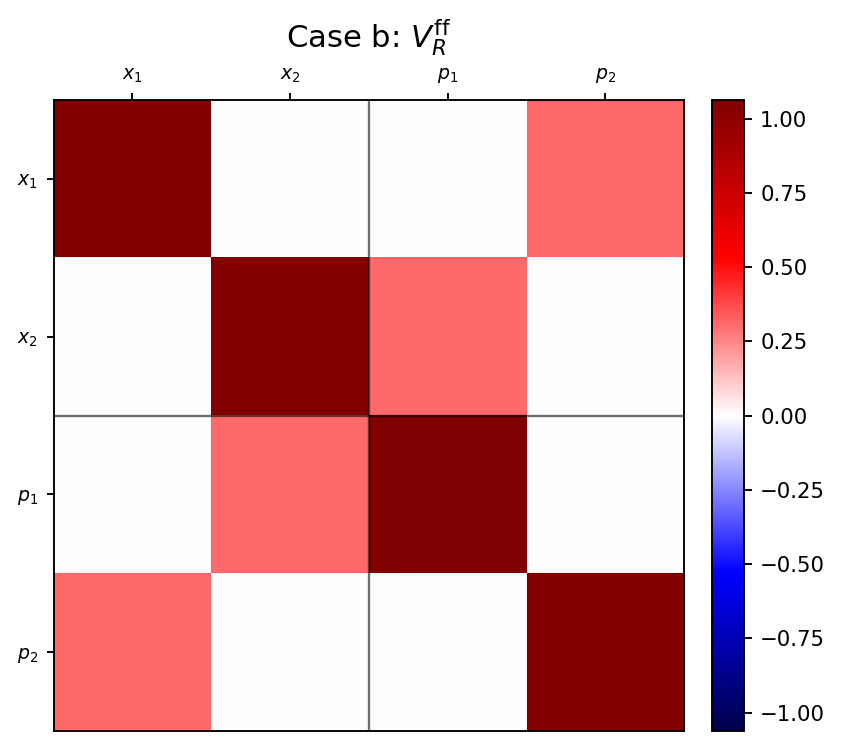

vmin=-1.06, vmax=1.06


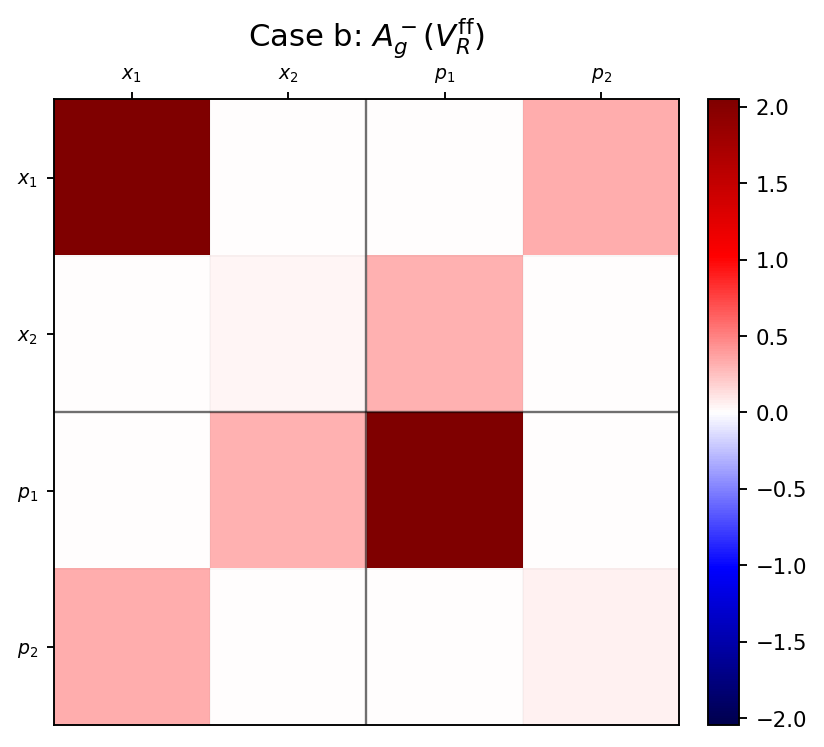

vmin=-2.05, vmax=2.05


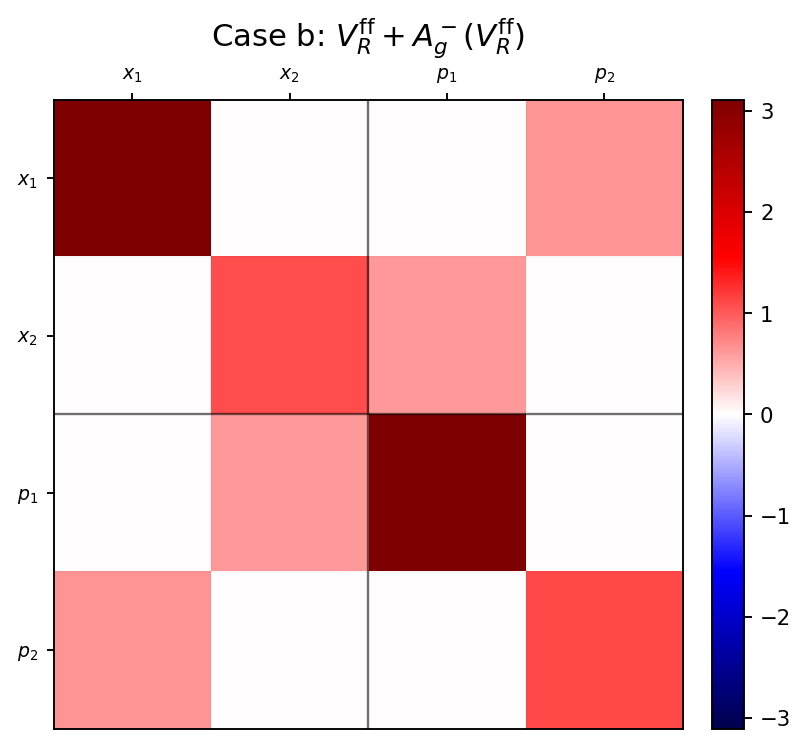

vmin=-3.11, vmax=3.11


In [32]:
# ============================================================
# 3.2.2 A_R, V_R matrix layer
# Case b: deletion 먼저, photon subtraction 나중
# ============================================================

draw_phase_matrix(
    V_R_post,
    title=rf"Case b: $V_R^{{\rm ff}}$",
    positive=False,
    cmap="seismic",
    tick_step=1,
    figsize=(5, 4.5),
    grid=True
)

draw_phase_matrix(
    A_R_post,
    title=rf"Case b: $A^-_g(V_R^{{\rm ff}})$",
    positive=False,
    cmap="seismic",
    tick_step=1,
    figsize=(5, 4.5),
    grid=True
)

draw_phase_matrix(
    V_actual_R_post,
    title=rf"Case b: $V_R^{{\rm ff}} + A^-_g(V_R^{{\rm ff}})$",
    positive=False,
    cmap="seismic",
    tick_step=1,
    figsize=(5, 4.5),
    grid=True
)

In [33]:
# ============================================================
# 3.2.3 Graph layer - kurtosis only
# Case b: deletion 먼저, photon subtraction 나중
#
# Inputs:
#   V_R_post : Gaussian envelope after deletion
#   A_R_post : non-Gaussian correction after photon subtraction on deleted graph
#   R0       : remaining nodes, 0-based original labels
#   j_local0 : target node local index in R-space, 0-based
#
# ordering in reduced R-space:
#   q_R = (x_R, p_R)
# ============================================================

V_eff = V_R_post
A_eff = A_R_post

r = len(R0)
R_labels = list(R0 + 1)   # original node labels, 1-based

def excess_kurtosis_1d(v, a):
    """
    chi(lambda) = exp[-v lambda^2 / 2] * (1 - a lambda^2 / 2)

    actual variance = v + a
    excess kurtosis = -3 a^2 / (v+a)^2
    """
    var = v + a
    if np.isclose(var, 0):
        return np.nan
    return -3 * a**2 / var**2


# node별 x, p kurtosis 계산
Kex_x_post = np.zeros(r)
Kex_p_post = np.zeros(r)

var_x_actual_post = np.zeros(r)
var_p_actual_post = np.zeros(r)

v_x_env_post = np.zeros(r)
v_p_env_post = np.zeros(r)

a_x_post = np.zeros(r)
a_p_post = np.zeros(r)

for k in range(r):
    x_idx = k
    p_idx = k + r

    # x quadrature
    v_x_env_post[k] = V_eff[x_idx, x_idx]
    a_x_post[k] = A_eff[x_idx, x_idx]
    var_x_actual_post[k] = v_x_env_post[k] + a_x_post[k]
    Kex_x_post[k] = excess_kurtosis_1d(v_x_env_post[k], a_x_post[k])

    # p quadrature
    v_p_env_post[k] = V_eff[p_idx, p_idx]
    a_p_post[k] = A_eff[p_idx, p_idx]
    var_p_actual_post[k] = v_p_env_post[k] + a_p_post[k]
    Kex_p_post[k] = excess_kurtosis_1d(v_p_env_post[k], a_p_post[k])


# table
kurtosis_post_df = pd.DataFrame({
    "node": R_labels,
    "v_x_env": v_x_env_post,
    "a_x": a_x_post,
    "var_x_actual": var_x_actual_post,
    "Kex_x": Kex_x_post,
    "v_p_env": v_p_env_post,
    "a_p": a_p_post,
    "var_p_actual": var_p_actual_post,
    "Kex_p": Kex_p_post,
})

display(kurtosis_post_df.style.format("{:.4f}", subset=kurtosis_post_df.columns[1:]))

print("target original node =", j)
print("target local index =", j_local)
print("target Kex_x =", Kex_x_post[j_local0])
print("target Kex_p =", Kex_p_post[j_local0])

,node,v_x_env,a_x,var_x_actual,Kex_x,v_p_env,a_p,var_p_actual,Kex_p
0,1,1.0471,2.0482,3.0953,-1.3135,1.0622,2.0482,3.1103,-1.3009
1,2,1.0471,0.0461,1.0932,-0.0053,1.0492,0.0503,1.0995,-0.0063


target original node = 2
target local index = 2
target Kex_x = -0.005334314305541076
target Kex_p = -0.006280640592560205


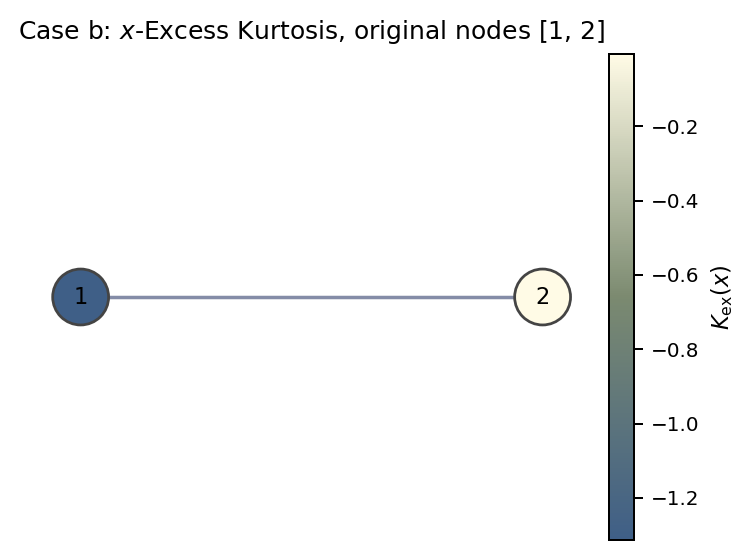

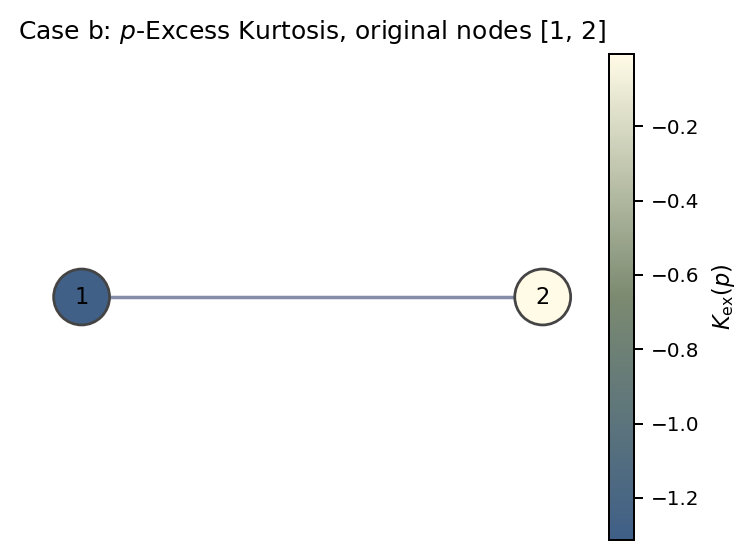

In [34]:
# ============================================================
# 3.2.3 Graph layer - kurtosis reflected graph
# Case b: deletion 먼저, photon subtraction 나중
# ============================================================

# Reduced graph position and labels
pos_R = {
    local_idx: pos[int(original_idx)]
    for local_idx, original_idx in enumerate(R0)
}

labels_R = {
    local_idx: int(original_idx) + 1
    for local_idx, original_idx in enumerate(R0)
}

# common color scale for x and p kurtosis
vmin_K_post = min(np.nanmin(Kex_x_post), np.nanmin(Kex_p_post))
vmax_K_post = max(np.nanmax(Kex_x_post), np.nanmax(Kex_p_post))

# x-quadrature excess kurtosis graph
pos_R = plot_graph_from_matrix(
    Gamma_R,
    node_values=Kex_x_post,
    title=rf"Case b: $x$-Excess Kurtosis, original nodes {list(R0 + 1)}",
    pos=pos_R,
    labels=labels_R,
    draw_labels=True,
    cmap=blue,
    vmin=vmin_K_post,
    vmax=vmax_K_post,
    colorbar_label=r"$K_{\rm ex}(x)$"
)

# p-quadrature excess kurtosis graph
pos_R = plot_graph_from_matrix(
    Gamma_R,
    node_values=Kex_p_post,
    title=rf"Case b: $p$-Excess Kurtosis, original nodes {list(R0 + 1)}",
    pos=pos_R,
    labels=labels_R,
    draw_labels=True,
    cmap=blue,
    vmin=vmin_K_post,
    vmax=vmax_K_post,
    colorbar_label=r"$K_{\rm ex}(p)$"
)

reduced node 1  <->  original node 1


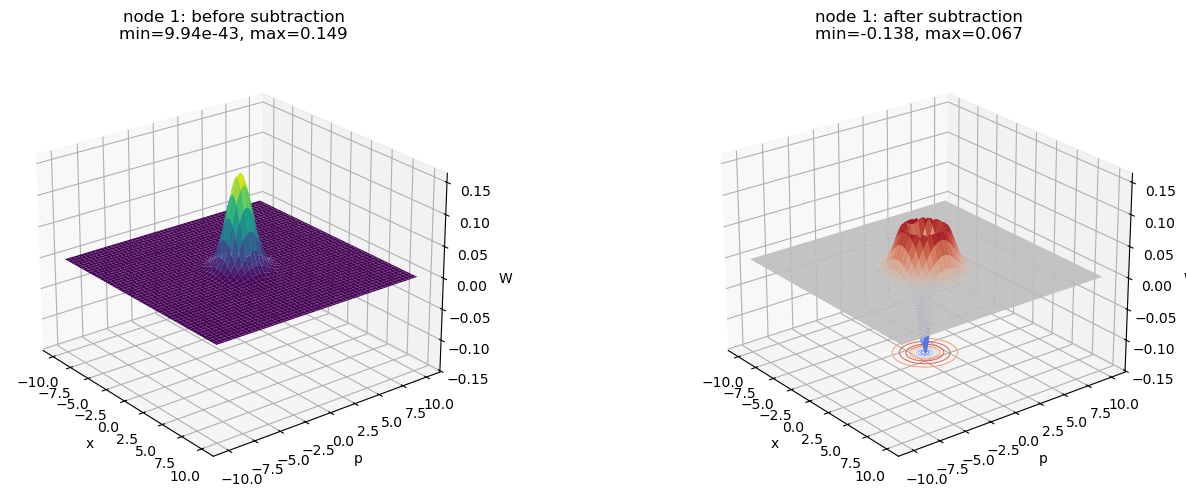

reduced node 2  <->  original node 2


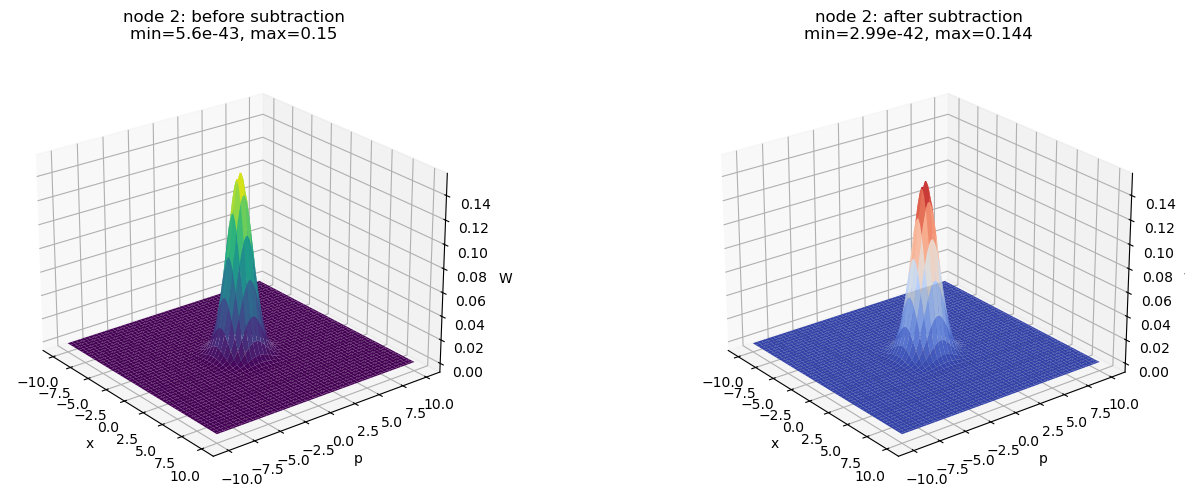

In [35]:
# ============================================================
# 3.2.3 Graph layer - single-mode Wigner function
# Case b: deletion 먼저, photon subtraction 나중
#
# V_eff = V_R_post
# A_eff = A_R_post
# node index는 reduced-space 기준: 1,2,...,r
# ============================================================

V_eff = V_R_post
A_eff = A_R_post

r = len(R0)
R_labels = list(R0 + 1)

nodes_to_plot = range(1, r + 1)

plot_static = True
plot_interactive = False

for node in nodes_to_plot:
    original_node = R_labels[node - 1]

    print("=" * 60)
    print(f"reduced node {node}  <->  original node {original_node}")

    if plot_static:
        plot_node_wigner_3d_static(
            V_eff,
            A_eff,
            node=node,
            m=r,
            xlim=10,
            n=100
        )

    if plot_interactive:
        plot_node_wigner_3d_interactive(
            V_eff,
            A_eff,
            node=node,
            m=r,
            xlim=10,
            n=100
        )

In [36]:
# ============================================================
# Interactive single-mode Wigner plot
# Case b: deletion 먼저, photon subtraction 나중
#
# Inputs:
#   V_R_post, A_R_post, R0
#
# ordering:
#   q_R = (x_R, p_R)
# ============================================================

R_labels = list(R0 + 1)
r = len(R_labels)

for local_node in range(1, r + 1):
    original_node = R_labels[local_node - 1]

    X, P, W, V1, A1 = plot_single_mode_wigner_interactive(
        V_R_post,
        A_R_post,
        node=local_node,
        m_eff=r,
        original_label=original_node,
        xlim=10,
        n=160
    )

local node 1 -> original node 1
V1 =
[[1.04712855 0.        ]
 [0.         1.06216285]]
A1 =
[[2.04815835 0.        ]
 [0.         2.04815835]]
Tr(V1^{-1} A1) = 3.8842663675944813
W(0) negativity condition Tr > 2 ? True
min W = -0.14055191980794185
max W = 0.06698821072054978
has negativity? True


local node 2 -> original node 2
V1 =
[[1.04712855 0.        ]
 [0.         1.04923416]]
A1 =
[[0.04609875 0.        ]
 [0.         0.05030996]]
Tr(V1^{-1} A1) = 0.091973187681893
W(0) negativity condition Tr > 2 ? False
min W = 2.9910925052044615e-42
max W = 0.14433726890330734
has negativity? False


In [37]:
# ============================================================
# Single-photon fidelity after homodyne measurement + feed-forward
#
# Inputs:
#   V_R_ff, A_R_ff, R0
#
# R0:
#   remaining original node indices, 0-based
#
# reduced system ordering:
#   q_R = (x_R, p_R)
# ============================================================

R_labels = list(R0 + 1)   # original node labels
print("Remaining nodes R =", R_labels)
r = len(R_labels)         # number of remaining modes

F0_vals = []
F1_vals = []

for local_node in range(1, r + 1):
    original_node = R_labels[local_node - 1]

    # local_node 기준으로 single-mode reduced V,A 추출
    V_k, A_k, inds = reduced_matrices(
        V_R_post,
        A_R_post,
        subset=[local_node],
        m=r
    )

    F0, F1 = fock01_fidelity_from_VA(V_k, A_k)

    F0_vals.append(F0)
    F1_vals.append(F1)

    print(
        f"local node {local_node} -> original node {original_node}: "
        f"F0 = {F0:.6f}, F1 = {F1:.6f}, F0+F1 = {F0+F1:.6f}"
    )

F0_vals = np.array(F0_vals)
F1_vals = np.array(F1_vals)

df_F = pd.DataFrame({
    "local node": np.arange(1, r + 1),
    "original node": R_labels,
    "F0 = <0|rho|0>": F0_vals,
    "F1 = <1|rho|1>": F1_vals,
    "F0 + F1": F0_vals + F1_vals,
})

display(df_F)

print()
print("max F1 =", np.max(F1_vals))
print("max F1 original node =", R_labels[np.argmax(F1_vals)])




Remaining nodes R = [1, 2]
local node 1 -> original node 1: F0 = 0.003060, F1 = 0.944649, F0+F1 = 0.947709
local node 2 -> original node 2: F0 = 0.953495, F1 = 0.044870, F0+F1 = 0.998365


,local node,original node,F0 = <0|rho|0>,F1 = <1|rho|1>,F0 + F1
0,1,1,0.003060,0.944649,0.947709
1,2,2,0.953495,0.044870,0.998365



max F1 = 0.944648943190912
max F1 original node = 1


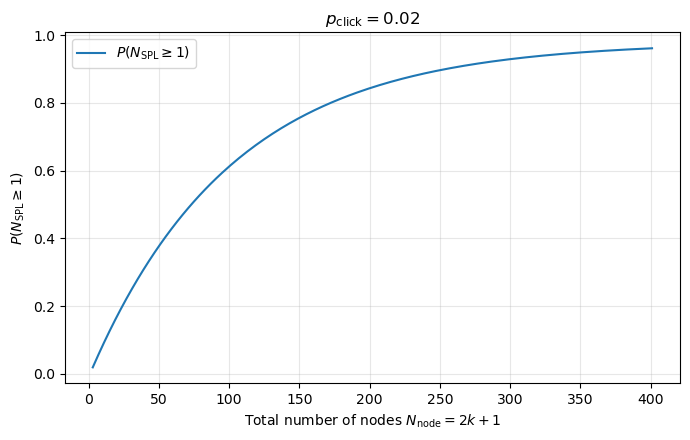

k =   1,  N_node =   3,  P(N_SPL >= 1) = 0.019208 (1.92%)
k =   5,  N_node =  11,  P(N_SPL >= 1) = 0.092348 (9.23%)
k =  10,  N_node =  21,  P(N_SPL >= 1) = 0.175994 (17.60%)
k =  20,  N_node =  41,  P(N_SPL >= 1) = 0.320383 (32.04%)
k =  50,  N_node = 101,  P(N_SPL >= 1) = 0.615757 (61.58%)
k = 100,  N_node = 201,  P(N_SPL >= 1) = 0.844619 (84.46%)
k -> infinity, P(N_SPL >= 1) -> 0.980000 (98.00%)


In [39]:
import numpy as np
import matplotlib.pyplot as plt

# click probability
p_click = 0.02

# number of outer pairs
k_values = np.arange(1, 201)

# total number of nodes
N_node = 2 * k_values + 1

# success probability per outer pair
# only one designated outer click is counted as success
p_pair_success = p_click * (1 - p_click)

# total success probability
# center node click events are discarded
P_success = (1 - p_click) * (1 - (1 - p_pair_success) ** k_values)

# plot
plt.figure(figsize=(7, 4.5))
plt.plot(N_node, P_success, label=r"$P(N_{\rm SPL}\geq 1)$")
plt.xlabel(r"Total number of nodes $N_{\rm node}=2k+1$")
plt.ylabel(r"$P(N_{\rm SPL}\geq 1)$")
plt.title(rf"$p_{{\rm click}}={p_click}$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# print selected values
for k in [1, 5, 10, 20, 50, 100]:
    N = 2 * k + 1
    P = (1 - p_click) * (1 - (1 - p_pair_success) ** k)
    print(
        f"k = {k:3d},  N_node = {N:3d},  "
        f"P(N_SPL >= 1) = {P:.6f} ({100*P:.2f}%)"
    )

print(f"k -> infinity, P(N_SPL >= 1) -> {1 - p_click:.6f} ({100*(1-p_click):.2f}%)")